# 04 · k-En Yakın Komşu ve Örnek Tabanlı Öğrenme (k-Nearest Neighbors & Instance-Based Learning)
**Classical ML Lab** · Model Öğrenmeyen Model: Veriyi Ezberleyip Komşularına Danışan Algoritmalar

---
> **Bu notebook'ta ne öğreneceğiz?**
> `02_linear_regression_family` ve `03_linear_classification_family`'de gördüğümüz tüm yöntemler **parametrik**ti: eğitim verisinden sabit sayıda katsayı ($\beta$) öğrenip veriyi bir kenara bırakıyorlardı. Bu notebook'ta tamamen farklı bir felsefeye geçiyoruz — **örnek tabanlı (instance-based) / tembel (lazy) öğrenme**: model, eğitim verisini olduğu gibi saklar ve her yeni tahmin için "bu noktaya en çok kim benziyor?" sorusunu doğrudan veriye sorar.
>
> - **k-NN Sınıflandırma:** Yeni bir noktayı, en yakın $k$ komşusunun çoğunluk oyuyla (ya da mesafe-ağırlıklı oyuyla) sınıflandırma
> - **k-NN Regresyon:** Sürekli bir hedefi, en yakın $k$ komşunun ortalamasıyla (ya da ağırlıklı ortalamasıyla) tahmin etme — emlakçıların "benzer satışlar (comparables)" yöntemiyle birebir aynı mantık
> - **Nearest Centroid:** Her sınıfın "prototipine" (ortalama vektörüne) en yakın olanı seçen, KNN'den daha basit bir örnek-tabanlı sınıflandırıcı
> - **Mesafe Metrikleri:** Euclidean, Manhattan, Minkowski, Cosine, Hamming — hangi veri tipinde hangisi kullanılır
> - **Boyut Laneti (Curse of Dimensionality):** Yüksek boyutta "yakınlık" kavramının neden anlamını yitirdiği, ve KNN'i neden doğrudan etkilediği
> - **k Seçimi ve Ölçekleme:** Bias-variance ödünleşimi, cross-validation, ve mesafe-tabanlı bir yöntem için ölçeklemenin neden opsiyonel değil zorunlu olduğu
> - **Hesaplama Verimliliği:** Brute-force arama vs KD-Tree/Ball-Tree — komşu aramanın algoritmik maliyeti
>
> Her bölümü, yöntemin **gerçekten hangi endüstride, hangi karara** hizmet ettiğini göstererek işliyoruz (öneri sistemleri, emlak değerlemesi, sahtecilik tespiti, genomik sınıflandırma) — amaç "bu yöntemi ne zaman seçerim, ne zaman seçmem?" sorusuna iş hayatında cevap verebilmek.
>
> **Önkoşul:** `03_linear_classification_family` (sınıflandırma kavramları, karar sınırı), `01_data_prepreparation` (ölçekleme)
> **Veri:** Iris (UCI/sklearn), Diabetes (sklearn, Efron et al. 2004), Ionosphere (UCI, radar sinyali sınıflandırması)
> **Araçlar:** Python (`scikit-learn`), R (`class::knn`, `FNN::knn.reg`), SQL (`DuckDB`)

---
## 1 · Genel Çerçeve: Parametrik vs Örnek Tabanlı (Lazy) Öğrenme

Şimdiye kadar gördüğümüz her yöntem (Lojistik Regresyon, LDA/QDA, Perceptron, SGD, ...) **parametriktir**: eğitim sırasında sabit sayıda parametre ($\beta$ katsayıları, sınıf ortalamaları/kovaryansları) tahmin edilir, eğitim verisi bu parametrelere "sıkıştırılır" ve tahmin anında artık gerek duyulmaz. k-NN bunun tam tersini yapar — **hiçbir parametre öğrenmez**, sadece eğitim verisinin tamamını olduğu gibi saklar ("ezberler") ve her yeni tahmin isteğinde **doğrudan veriye danışır**: "bu yeni noktaya en çok hangi eğitim örnekleri benziyor?"

Bu ayrım literatürde **eager learning** (istekli öğrenme — parametrik modeller, eğitim anında iş biter) vs **lazy learning** (tembel öğrenme — k-NN, işi tahmin anına erteler) olarak adlandırılır:

| Yön | Parametrik / Eager (ör. Lojistik Regresyon) | Örnek Tabanlı / Lazy (k-NN) |
|---|---|---|
| Eğitim maliyeti | Yüksek (optimizasyon: gradyan inişi, MLE, ...) | Neredeyse sıfır — veriyi kopyalamak/indekslemek |
| Tahmin maliyeti | Düşük (tek bir dot product: $x^\top\beta$) | Yüksek — her tahmin için tüm veriyle mesafe hesabı |
| Bellek | Küçük (sadece $\beta$ vektörü) | Büyük — tüm eğitim verisi saklanır |
| Karar sınırı şekli | Modelin varsayımıyla sınırlı (ör. doğrusal) | Esnek, veri yoğunluğuna göre şekillenir — **non-parametrik** |
| Yorumlanabilirlik | Yüksek (katsayı = etki büyüklüğü) | Düşük ("neden bu tahmin?" sorusunun cevabı = "bu k komşu") |

k-NN'in **non-parametrik** doğası önemli bir teorik garantiye sahiptir: Cover & Hart'ın 1967 tarihli klasik makalesi, eğitim örneği sayısı $n \to \infty$ giderken 1-NN sınıflandırıcının hata oranının, teorik olarak mümkün olan en iyi sınıflandırıcının (Bayes optimal) hata oranının **en fazla iki katına** yakınsadığını kanıtlar — hiçbir dağılım varsayımı yapmadan. Bu, k-NN'i basitliğine rağmen teorik olarak güçlü kılan sonuçtur.

**Endüstride nerede kullanılır?** Öneri sistemlerinin en eski ve hâlâ yaygın ailesi olan **komşuluk-tabanlı işbirlikçi filtreleme (neighborhood-based collaborative filtering)** tam olarak bu fikri kullanır — Amazon'un "bunu alanlar şunu da aldı" özelliği, kullanıcı/ürün benzerlik uzayında en yakın komşuları bulmaya dayanır. İçerik-tabanlı görsel arama (reverse image search, Pinterest'in "benzer görselleri bul" özelliği) da aynı mantıkla, görsellerin öznitelik vektörleri arasında en yakın komşuyu arar.

---
## 2 · Mesafe Metrikleri: "Yakınlık" Nasıl Tanımlanır?

k-NN'in tüm mantığı "yakınlık" kavramına dayandığından, mesafe metriğinin seçimi modelin davranışını doğrudan belirler. En yaygın kullanılan beş metrik:

**Minkowski Mesafesi (genel form):**
$$d_p(x, y) = \left(\sum_{i=1}^{d} |x_i - y_i|^p\right)^{1/p}$$

Bu, $p$ parametresine göre birkaç özel durumu kapsayan bir aile tanımlar:

| Metrik | $p$ | Formül | Ne zaman kullanılır | Endüstri örneği |
|---|---|---|---|---|
| **Manhattan (L1)** | $p=1$ | $\sum\lvert x_i-y_i\rvert$ | Izgara-benzeri hareket, yüksek boyutlu veride L2'ye göre bazen daha dayanıklı (Aggarwal, Hinneburg & Keim 2001) | Şehir bloğu/teslimat rotası mesafesi, seyrek özellik vektörleri |
| **Euclidean (L2)** | $p=2$ | $\sqrt{\sum(x_i-y_i)^2}$ | Genel amaçlı, düşük-orta boyutlu sürekli veri | Sensör ölçümleri, fiziksel konum verisi |
| **Chebyshev (L∞)** | $p\to\infty$ | $\max_i\lvert x_i-y_i\rvert$ | En kötü-durum/tek-boyut farkı önemliyse | Satranç tahtasında kral hamlesi, kalite kontrolde en sapan ölçüm |

**Cosine Mesafesi** (büyüklükten bağımsız, sadece **açıyı** ölçer):
$$d_{\cos}(x,y) = 1 - \frac{x \cdot y}{\lVert x\rVert \lVert y\rVert}$$
Vektörlerin *büyüklüğü* değil *yönü* önemliyse idealdir — özellikle metin verisinde (TF-IDF vektörleri) iki doküman farklı uzunlukta olsa da aynı konudan bahsediyorsa cosine mesafesi küçük çıkar, Euclidean ise uzunluk farkından yanılabilir.

**Hamming Mesafesi** (kategorik/ikili öznitelikler için):
$$d_H(x,y) = \sum_{i=1}^{d} \mathbb{1}[x_i \neq y_i]$$
Sadece "kaç konumda farklılar" sayar — sürekli mesafe kavramı olmayan kategorik/ikili verilerde (one-hot kodlanmış öznitelikler, DNA dizileri) kullanılır.

**Endüstride nerede kullanılır?** Arama motorları ve doküman benzerliği (bilgi erişimi) sistemleri neredeyse evrensel olarak **cosine mesafesi** kullanır — TF-IDF/embedding vektörlerinin boyutu (doküman uzunluğu) benzerlik yargısını bozmasın diye. Genetik dizi eşleştirme ve hata düzeltme kodlarında (telekomünikasyon) **Hamming mesafesi** standarttır. Manhattan mesafesi, yüksek boyutlu (yüksek-$d$) veride Euclidean'a kıyasla nispeten daha az "küçülen" ayrım gücü sağladığı için (bkz. Bölüm 6, Boyut Laneti) bazı yüksek boyutlu uygulamalarda tercih edilir.

---
## 3 · k-NN Sınıflandırma

**Algoritma:** Yeni bir $x$ noktası için, eğitim verisindeki en yakın $k$ komşuyu bul ($N_k(x)$), ve $x$'i bu komşular arasında **en sık görülen sınıfa** ata:
$$\hat{y} = \underset{c}{\text{argmax}} \sum_{i \in N_k(x)} \mathbb{1}[y_i = c]$$

**Mesafe-ağırlıklı oylama (distance-weighted voting):** Her komşunun oyu eşit sayılmak zorunda değil — daha yakın komşulara daha fazla ağırlık verilebilir (tipik seçim $w_i = 1/d(x,x_i)$):
$$\hat{y} = \underset{c}{\text{argmax}} \sum_{i \in N_k(x)} w_i \cdot \mathbb{1}[y_i = c]$$
Bu, $k$ büyük seçildiğinde uzak komşuların kararı gereksiz yere bulandırmasını engeller.

**Karar sınırı ve Voronoi ilişkisi:** $k=1$ özel durumunda karar sınırı, her eğitim noktasının "sahip olduğu" bölgeyi (Voronoi hücresi — o noktaya diğer tüm noktalardan daha yakın olan bölge) tanımlayan **Voronoi diyagramı**nın, farklı sınıftaki hücreler arasındaki kenarlarının birleşimidir. $k$ arttıkça sınır giderek pürüzsüzleşir (Bölüm 7'de detaylı).

**Endüstride nerede kullanılır?** Kredi kartı sahtecilik tespitinde, yeni bir işlem "geçmişte sahtekârlık olarak işaretlenmiş en benzer $k$ işleme" ne kadar yakınsa o kadar şüpheli sayılabilir — büyük bankalarda kural-tabanlı sistemlerin yanında hâlâ kullanılan basit ama etkili bir yaklaşım. Tıbbi teşhiste **vaka-tabanlı akıl yürütme (case-based reasoning)**, yeni bir hastanın semptom/laboratuvar profiline en çok benzeyen geçmiş vakalara bakarak tanı önerisi sunar.

---
## 4 · k-NN Regresyon

Hedef artık kategorik değil sürekli olduğunda, "çoğunluk oyu" yerine **komşuların ortalaması** (ya da mesafe-ağırlıklı ortalaması) kullanılır:
$$\hat{y} = \frac{1}{k}\sum_{i \in N_k(x)} y_i \qquad \text{(uniform)} \qquad\qquad \hat{y} = \frac{\sum_{i \in N_k(x)} w_i\, y_i}{\sum_{i \in N_k(x)} w_i} \qquad \text{(ağırlıklı, } w_i = 1/d(x,x_i)\text{)}$$

**Endüstride nerede kullanılır?** Bu yöntem, emlak değerleme uzmanlarının (appraiser) manuel olarak yaptığı **"benzer satışlar" (comparable sales / "comps") yöntemi**yle matematiksel olarak birebir aynıdır: bir evin değeri, yakın zamanda satılmış, benzer özelliklere (metrekare, oda sayısı, konum) sahip $k$ evin satış fiyatının ortalaması alınarak tahmin edilir — k-NN regresyon bunun otomatikleştirilmiş, tutarlı versiyonudur. Enerji şirketleri, yarının elektrik talebini tahmin ederken geçmişte benzer hava koşullarına/gün tipine (hafta içi/sonu, sıcaklık, mevsim) sahip günlerin ortalama tüketimine bakan bir k-NN yaklaşımı kullanabilir.

---
## 5 · Nearest Centroid Classifier

k-NN'den daha da basit bir örnek-tabanlı yaklaşım: her tahmin için *tüm* eğitim verisine bakmak yerine, her sınıf için tek bir "prototip" (centroid — sınıf içi ortalama vektör) hesapla, ve yeni noktayı **en yakın centroid'in sınıfına** ata:
$$\mu_k = \frac{1}{n_k}\sum_{i:\, y_i=k} x_i \qquad\qquad \hat{y} = \underset{k}{\text{argmin}}\; d(x, \mu_k)$$

Bu, `03_linear_classification_family`'de gördüğümüz **LDA**'nın özel bir hâlidir: LDA, sınıfların ortak bir kovaryans matrisine sahip çok değişkenli Normal dağılımdan geldiğini varsayıp Mahalanobis mesafesiyle en yakın sınıfı seçer; kovaryans matrisi **birim matris** (küresel/spherical, tüm özellikler eşit varyanslı ve bağımsız) olduğunda LDA tam olarak Nearest Centroid'e indirgenir. Bilgi erişiminde (information retrieval) bu fikir **Rocchio algoritması** olarak bilinir — bir sorguyu, ilgili dokümanların ortalama vektörüne (centroid) yaklaştırarak iyileştirme (relevance feedback).

**Endüstride nerede kullanılır?** Metin sınıflandırmada Rocchio algoritması, erken dönem arama motorlarında sorgu genişletme için kullanıldı. Genomikte, **Shrunken Centroids (PAM — Prediction Analysis for Microarrays, Tibshirani ve ark. 2002)** yöntemi, binlerce gen ifadesi özelliğine sahip ama az sayıda hasta örneği olan kanser alt-tipi sınıflandırma problemlerinde Nearest Centroid'in düzenlileştirilmiş bir versiyonunu kullanır — hem KNN'den (hesaplama ucuzluğu) hem LDA'dan (kovaryans tahmini gerektirmemesi, boyut lanetine dayanıklılık) avantajlıdır.

---
## 6 · Boyut Laneti (Curse of Dimensionality)

k-NN'in temel varsayımı şudur: **"birbirine yakın noktalar birbirine benzer."** Bu varsayım düşük boyutta (2-3 özellik) sezgisel olarak doğrudur, ama özellik sayısı ($d$) arttıkça çarpıcı biçimde çöker — bu olguya **boyut laneti** denir.

**Neden olur?** Sabit sayıda $n$ eğitim noktasıyla, $d$-boyutlu uzamda veri yoğunluğu $d$ arttıkça **üstel olarak** seyrekleşir (hacim $d$ ile üstel büyür, ama nokta sayısı sabit kalır). Bu seyrekleşmenin somut sonucu, **mesafelerin ayırt ediciliğini kaybetmesidir**: Beyer ve arkadaşlarının (1999) gösterdiği üzere, çoğu veri dağılımı için $d\to\infty$ giderken, rastgele bir sorgu noktasına **en yakın** komşunun mesafesi ile **en uzak** komşunun mesafesi arasındaki oran 1'e yakınsar:
$$\frac{d_{max} - d_{min}}{d_{min}} \xrightarrow{d\to\infty} 0$$
Başka bir deyişle: yeterince yüksek boyutta, "en yakın" komşu ile "en uzak" komşu neredeyse aynı mesafede olur — mesafe kavramı anlamını yitirir, ve k-NN rastgele tahmin etmekten farksız hâle gelir.

**Pratik sonuç:** k-NN'i ham, yüksek boyutlu veriye (yüzlerce/binlerce özellik) doğrudan uygulamak genellikle başarısız olur. Çözüm: boyut indirgeme (PCA — bkz. `17_dimensionality_reduction_advanced`), özellik seçimi, veya sadece bilgilendirici özelliklerin tutulması.

**Endüstride nerede kullanılır (aslında: nerede k-NN'in başarısız olduğu ve neden)?** Genomik veride (gen ifadesi analizi) tipik olarak binlerce gen (özellik) ölçülür ama sadece yüzlerce hasta (örnek) vardır — bu "geniş ama sığ" (wide, shallow) veri yapısı boyut lanetinin klasik tuzağıdır; ham k-NN uygulamadan önce mutlaka boyut indirgeme veya özellik seçimi yapılır (bkz. Bölüm 5'teki Shrunken Centroids, PAM'ın bu soruna özel çözümü).

---
## 7 · k Seçimi: Bias-Variance Ödünleşimi

$k$, k-NN'in tek ama kritik hiperparametresidir, ve klasik bias-variance ödünleşimini doğrudan kontrol eder:

| $k$ | Bias | Varyans | Davranış |
|---|---|---|---|
| Küçük (ör. $k=1$) | Düşük | Yüksek | Karar sınırı çok pürüzlü, gürültüye aşırı duyarlı (overfitting) — tek bir aykırı değer bile sınıflandırmayı değiştirebilir |
| Büyük (ör. $k=n$) | Yüksek | Düşük | Karar sınırı düzleşir, her noktaya aynı (eğitim setinin genel çoğunluk sınıfı) tahmin verilir — underfitting |
| Orta (uygun) | Dengeli | Dengeli | Genelleme performansı en iyi noktada |

Pratikte optimal $k$, veri setine göre değişir ve genellikle **cross-validation** ile bulunur: farklı $k$ değerleri için doğrulama hatası hesaplanır, hata eğrisinin en düşük olduğu (ya da "dirsek" — elbow — noktasındaki) $k$ seçilir. Kaba bir başlangıç noktası olarak $k \approx \sqrt{n}$ kuralı literatürde sıkça anılır, ama bu sadece bir ısınma tahmini — kesin değer CV ile doğrulanmalıdır. Genel bir sezgisel kural: sınıf sayısının katı olmayan $k$ değerleri, oylamada berabere kalma (tie) ihtimalini azaltır.

---
## 8 · Ölçeklemenin Kritik Rolü

k-NN **saf mesafeye** dayandığından, özniteliklerin sayısal ölçeği doğrudan model davranışını belirler — bu, `01_data_prepreparation`'da genel bir iyi-pratik olarak öğrendiğimiz ölçeklemeyi, k-NN için **isteğe bağlı değil zorunlu** hâle getirir.

Somut örnek: bir müşteri veri setinde "yaş" (0-100 aralığı) ile "yıllık gelir" (0-200.000 aralığı) birlikte kullanılsa, Euclidean mesafe hesabında gelir farkındaki birkaç bin birimlik oynama, yaştaki tüm farkı **gölgede bırakır** — model neredeyse tamamen gelire göre komşu seçer, yaş bilgisi pratik olarak yok sayılır. `StandardScaler` (ortalama 0, std 1) ya da `MinMaxScaler` (0-1 aralığı) ile ölçekleme, tüm özniteliklerin mesafe hesabına **orantılı** katkı yapmasını sağlar. Bölüm Python 4'te bunu Ionosphere veri setinde ölçekli/ölçeksiz karşılaştırmasıyla somut olarak göreceğiz.

---
## 9 · Hesaplama Verimliliği: Brute-Force vs KD-Tree vs Ball-Tree

Naif ("brute-force") k-NN, her tahmin için eğitim setindeki **her** noktaya olan mesafeyi hesaplar: $n$ eğitim noktası ve $d$ özellik için tahmin başına $O(n \cdot d)$ maliyet — büyük veri setlerinde (milyonlarca satır) pratik olmaktan çıkar.

Bunu hızlandırmak için uzamsal indeks yapıları kullanılır:
- **KD-Tree (k-dimensional tree):** Veriyi özellik eksenlerine göre ikili ağaç şeklinde böler. Düşük-orta boyutta (kabaca $d \lesssim 20$) ortalama $O(d\log n)$ sorgu maliyeti sağlar — brute-force'a göre çok büyük kazanç.
- **Ball-Tree:** Veriyi iç içe geçmiş hiper-kürelere (ball) böler; KD-Tree'ye göre daha yüksek boyutlu veride ve Euclidean-dışı metriklerde (ör. Haversine, coğrafi koordinatlar) daha dayanıklıdır.
- **Brute-force:** Çok yüksek boyutlu veride (Bölüm 6'daki boyut laneti nedeniyle) hem KD-Tree hem Ball-Tree'nin avantajı kaybolur ve pratikte brute-force'a yakın performans gösterirler — bu da boyut lanetinin arama *yapılarını* da etkilediğinin bir kanıtıdır. scikit-learn, `algorithm='auto'` ile veri boyutuna göre otomatik seçim yapar.

Python 10'da bu üç algoritmayı gerçek zamanlama ölçümüyle karşılaştıracağız.

---
# 🐍 Python Uygulaması

Teori bölümündeki tüm kavramları, **3 gerçek veri setini** — her birini güçlü olduğu senaryoda kullanarak — adım adım uygulayacağız:

1. **Veri Hazırlama** — Iris, Diabetes, Ionosphere yükleme ve ilk inceleme
2. **k-NN Sınıflandırma Temelleri** — Iris'te farklı $k$ değerleriyle karar sınırı görselleştirme
3. **Mesafe-Ağırlıklı Oylama** — uniform vs distance-weighted oylama karşılaştırması
4. **Ölçeklemenin Etkisi** — Ionosphere'e sentetik bir "farklı ölçekli" sensör özniteliği ekleyip ölçeksiz/ölçekli performansı karşılaştırma
5. **k Seçimi** — cross-validation ile optimal $k$ arama, hata eğrisi
6. **Mesafe Metrikleri Karşılaştırması** — Euclidean vs Manhattan vs Cosine
7. **Nearest Centroid** — Iris'te k-NN ile karşılaştırma
8. **k-NN Regresyon** — Diabetes'te $k$ ve ağırlık etkisi
9. **Boyut Laneti** — ampirik gösterim (sentetik, artan boyut sayısı)
10. **Hesaplama Verimliliği** — brute-force vs KD-Tree vs Ball-Tree zamanlama
11. **Sentez** — tüm yöntemlerin karşılaştırma tablosu

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor, NearestCentroid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 📂 Python 1 — Veri Hazırlama: 3 Veri Seti

**Ne yapıyoruz?**
Üç veri setini `data/` klasöründen okuyoruz. **Iris** (UCI, sklearn) ve **Diabetes** (sklearn, Efron ve ark. 2004) ağ erişimi gerektirmeyen, sklearn'e gömülü klasik veri setleri; **Ionosphere** (UCI) ise `raw.githubusercontent.com` üzerinden güvenilir bir GitHub mirror'ından çekildi — radar sinyallerinin iyonosferden "iyi" (`g`, yapılı bir dönüş sinyali) mi "kötü" (`b`, gürültü) mü yansıdığını 33 sayısal öznitelikle sınıflandıran, gerçekten yüksek boyutlu (33 özellik, 351 gözlem) bir veri seti — hem ölçekleme hem boyut laneti bölümlerinde işimize yarayacak. `feature_2` sütunu veri setinin orijinal tanımında sabittir (her zaman 0), gerçek dünya veri temizliğinin bir parçası olarak çıkarıyoruz.

In [70]:
iris = pd.read_csv('data/iris.csv')
diabetes = pd.read_csv('data/diabetes.csv')
iono = pd.read_csv('data/ionosphere.csv')

print(f"Iris       : {iris.shape[0]} satir x {iris.shape[1]} sutun  (3 sinif: cicek turu)")
print(iris['species'].value_counts().to_string())
print()
print(f"Diabetes   : {diabetes.shape[0]} satir x {diabetes.shape[1]} sutun  (regresyon: hastalik ilerleme skoru)")
print(diabetes['disease_progression'].describe().round(2).to_string())
print()
print(f"Ionosphere : {iono.shape[0]} satir x {iono.shape[1]} sutun  (ikili: radar sinyali iyi/kotu)")
print(iono['label'].value_counts().to_string())

# feature_2 sabit (her zaman 0) -- veri setinin bilinen bir ozelligi, cikariyoruz
assert iono['feature_2'].nunique() == 1
iono = iono.drop(columns=['feature_2'])
iono_feat_cols = [c for c in iono.columns if c.startswith('feature_')]
print(f"\nIonosphere kullanilabilir oznitelik sayisi (feature_2 cikarildiktan sonra): {len(iono_feat_cols)}")

Iris       : 150 satir x 6 sutun  (3 sinif: cicek turu)
species
setosa        50
versicolor    50
virginica     50

Diabetes   : 442 satir x 11 sutun  (regresyon: hastalik ilerleme skoru)
count    442.00
mean     152.13
std       77.09
min       25.00
25%       87.00
50%      140.50
75%      211.50
max      346.00

Ionosphere : 351 satir x 36 sutun  (ikili: radar sinyali iyi/kotu)
label
g    225
b    126

Ionosphere kullanilabilir oznitelik sayisi (feature_2 cikarildiktan sonra): 33


### 🌸 Python 2 — k-NN Sınıflandırma Temelleri: Iris'te Karar Sınırları ($k$=1, 3, 5, 15)

**Ne yapıyoruz?**
Iris'in iki özniteliğini (`petal_length`, `petal_width` — çiçek türlerini en iyi ayıran ikili) kullanarak, farklı $k$ değerlerinin karar sınırını nasıl şekillendirdiğini görselleştiriyoruz. $k=1$'de sınırın çok pürüzlü (Voronoi hücrelerine benzer), $k$ arttıkça giderek pürüzsüzleştiğini bekliyoruz (Bölüm 3 ve 7).

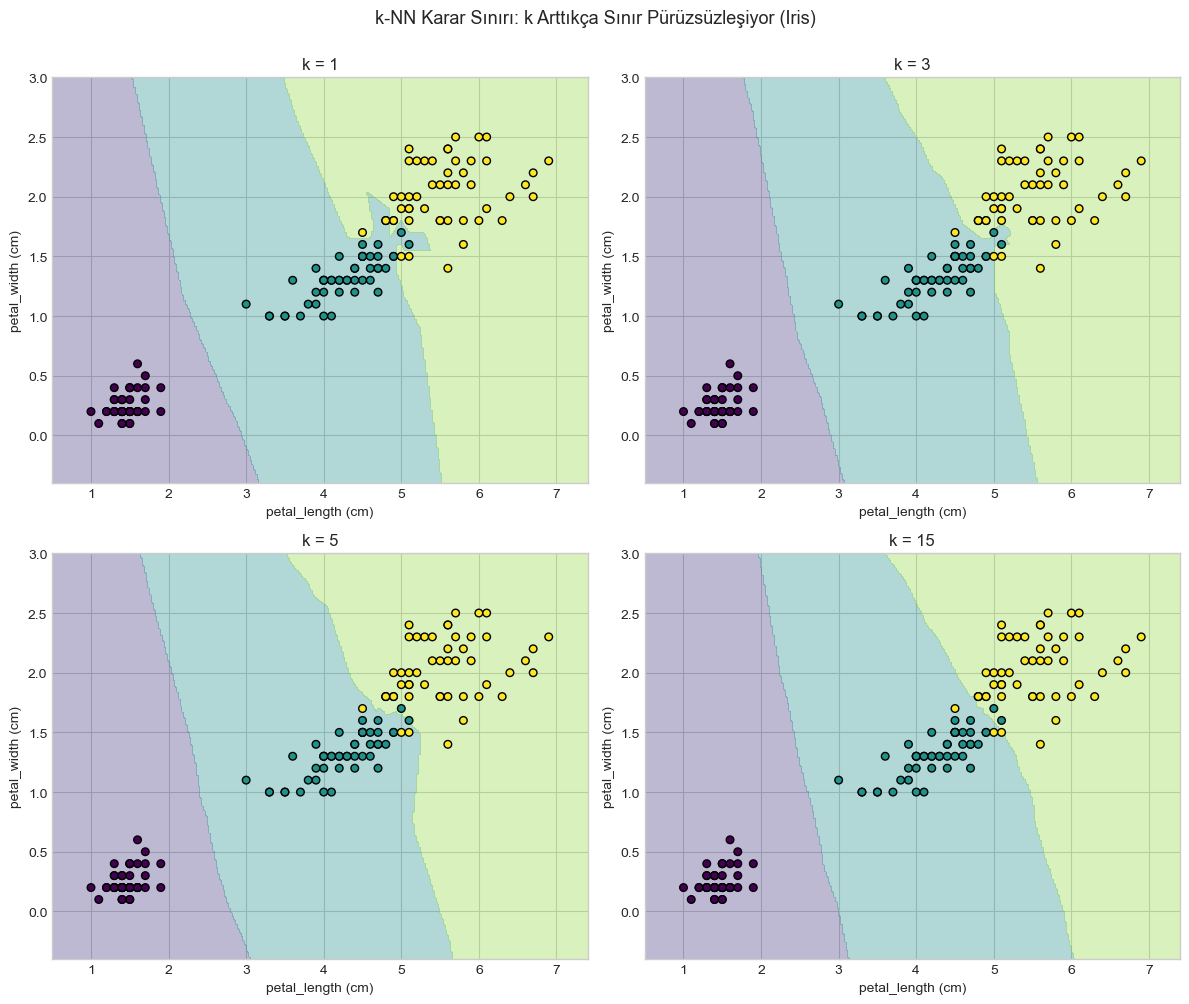

YORUM: k=1'de sinir her egitim noktasinin kendi Voronoi hucresini takip ediyor (pürüzlü,
gürültüye duyarli). k arttikca sinir düzlesiyor; k=15'te bile Iris'in üç sinifi net ayristigi
icin (dogrusal ayrilabilirlige yakin) asiri-pürüzsüzlesme (underfitting) henüz görülmüyor.


In [71]:
X2 = iris[['petal_length', 'petal_width']].values
y2 = iris['target'].values

xx, yy = np.meshgrid(np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 300),
                      np.linspace(X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5, 300))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, k in zip(axes.ravel(), [1, 3, 5, 15]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X2, y2)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap='viridis', levels=[-0.5, 0.5, 1.5, 2.5])
    scatter = ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap='viridis', edgecolor='k', s=30)
    ax.set_title(f"k = {k}")
    ax.set_xlabel('petal_length (cm)')
    ax.set_ylabel('petal_width (cm)')
plt.suptitle('k-NN Karar Sınırı: k Arttıkça Sınır Pürüzsüzleşiyor (Iris)', y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

print("YORUM: k=1'de sinir her egitim noktasinin kendi Voronoi hucresini takip ediyor (pürüzlü,")
print("gürültüye duyarli). k arttikca sinir düzlesiyor; k=15'te bile Iris'in üç sinifi net ayristigi")
print("icin (dogrusal ayrilabilirlige yakin) asiri-pürüzsüzlesme (underfitting) henüz görülmüyor.")

### ⚖️ Python 3 — Mesafe-Ağırlıklı Oylama: Uniform vs Distance

**Ne yapıyoruz?**
Iris'in tüm 4 özniteliğiyle, `weights='uniform'` (her komşu eşit oy) ve `weights='distance'` (yakın komşular daha ağırlıklı) seçeneklerini, artan $k$ değerleriyle karşılaştırıyoruz. Beklenti: $k$ küçükken iki yöntem benzer, $k$ büyüdükçe `distance` ağırlıklandırma uzak/yanlış-sınıf komşuların etkisini bastırdığı için daha dayanıklı kalmalı.

weights  distance  uniform
k                         
1          0.9333   0.9333
3          0.9556   0.9556
5          0.9778   0.9778
9          0.9556   0.9556
15         0.9778   0.9556
25         0.9556   0.9333


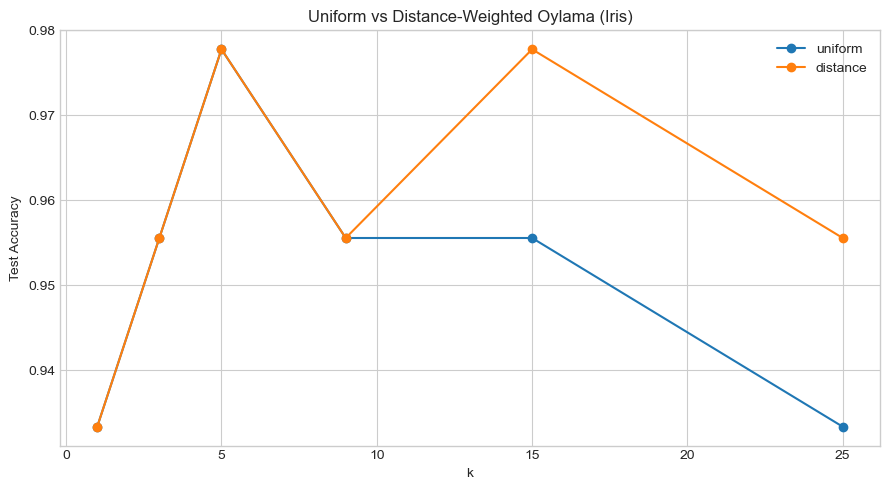


YORUM: k=25 gibi buyuk bir degerde uniform oylama 0.9333, distance-weighted
0.9556 accuracy veriyor -- mesafe agirlikli oylama, cok sayida (ve bazen
yanlis-sinif) uzak komsunun oyunu bastirarak buyuk k'larda daha dayanikli kalabiliyor.


In [72]:
Xtr, Xte, ytr, yte = train_test_split(
    iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values,
    iris['target'].values, test_size=0.3, random_state=42, stratify=iris['target'])

weight_results = []
for w in ['uniform', 'distance']:
    for k in [1, 3, 5, 9, 15, 25]:
        knn = KNeighborsClassifier(n_neighbors=k, weights=w).fit(Xtr, ytr)
        acc = accuracy_score(yte, knn.predict(Xte))
        weight_results.append({'weights': w, 'k': k, 'accuracy': acc})

weight_df = pd.DataFrame(weight_results)
pivot = weight_df.pivot(index='k', columns='weights', values='accuracy')
print(pivot.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
for w in ['uniform', 'distance']:
    sub = weight_df[weight_df['weights'] == w]
    ax.plot(sub['k'], sub['accuracy'], marker='o', label=w)
ax.set_xlabel('k')
ax.set_ylabel('Test Accuracy')
ax.set_title('Uniform vs Distance-Weighted Oylama (Iris)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nYORUM: k=25 gibi buyuk bir degerde uniform oylama {pivot.loc[25,'uniform']:.4f}, distance-weighted")
print(f"{pivot.loc[25,'distance']:.4f} accuracy veriyor -- mesafe agirlikli oylama, cok sayida (ve bazen")
print("yanlis-sinif) uzak komsunun oyunu bastirarak buyuk k'larda daha dayanikli kalabiliyor.")

### 📏 Python 4 — Ölçeklemenin Etkisi: Ionosphere'e Sentetik Bir "Farklı Ölçekli" Öznitelik Eklemek

**Ne yapıyoruz?**
Ionosphere'in orijinal 33 özniteliği zaten benzer bir aralıkta (yaklaşık $[-1, 1]$) olduğundan, ölçeklemenin etkisini **çarpıcı** biçimde göstermek için gerçekçi bir senaryo kuruyoruz: sahada yeni bir sensörden gelen, **çok farklı bir ham birimde** (mW cinsinden sinyal gücü, 500-5000 aralığında) bir öznitelik eklendiğini varsayalım — pratikte gerçek veri setlerine yeni bir kaynaktan öznitelik eklemek çok sık karşılaşılan bir durumdur. Bu tek öznitelik, ölçeklenmeden bırakılırsa Euclidean mesafeyi nasıl tek başına domine ettiğini göreceğiz (Bölüm 8).

In [73]:
np.random.seed(42)
iono_demo = iono.copy()
# Sentetik: yeni bir sensorden gelen, cok farkli ham birimde bir oznitelik (mW), hedefle hafifce iliskili
iono_demo['sinyal_gucu_mW'] = np.random.uniform(500, 5000, size=len(iono_demo)) + iono_demo['target'] * 300

demo_cols = iono_feat_cols + ['sinyal_gucu_mW']
Xi = iono_demo[demo_cols].values
yi = iono_demo['target'].values
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, yi, test_size=0.3, random_state=42, stratify=yi)

# Olceksiz
knn_unscaled = KNeighborsClassifier(n_neighbors=5).fit(Xi_tr, yi_tr)
acc_unscaled = accuracy_score(yi_te, knn_unscaled.predict(Xi_te))

# Olcekli (StandardScaler egitim setine fit edilip her ikisine de uygulanir -- veri sizintisi olmadan)
scaler_demo = StandardScaler().fit(Xi_tr)
Xi_tr_s, Xi_te_s = scaler_demo.transform(Xi_tr), scaler_demo.transform(Xi_te)
knn_scaled = KNeighborsClassifier(n_neighbors=5).fit(Xi_tr_s, yi_tr)
acc_scaled = accuracy_score(yi_te, knn_scaled.predict(Xi_te_s))

majority_frac = max((yi_te == 1).mean(), (yi_te == 0).mean())
print(f"Olceksiz  (34 oznitelik, biri 500-5000 araliginda) accuracy : {acc_unscaled:.4f}")
print(f"Olcekli   (StandardScaler sonrasi)                 accuracy : {acc_scaled:.4f}")
print(f"Cogunluk sinif orani (naif taban cizgi)             oran    : {majority_frac:.4f}")
print(f"\nYORUM: Tek bir yanlis-olcekli oznitelik, Euclidean mesafeyi tek basina domine edip modeli")
print("neredeyse cogunluk-sinif tahminine yakin bir yere dusuruyor -- StandardScaler ile bu etki")
print("tamamen ortadan kalkiyor, dogruluk olcekleme-oncesi/sonrasi seviyesine geri donuyor.")

Olceksiz  (34 oznitelik, biri 500-5000 araliginda) accuracy : 0.5566
Olcekli   (StandardScaler sonrasi)                 accuracy : 0.8585
Cogunluk sinif orani (naif taban cizgi)             oran    : 0.6415

YORUM: Tek bir yanlis-olcekli oznitelik, Euclidean mesafeyi tek basina domine edip modeli
neredeyse cogunluk-sinif tahminine yakin bir yere dusuruyor -- StandardScaler ile bu etki
tamamen ortadan kalkiyor, dogruluk olcekleme-oncesi/sonrasi seviyesine geri donuyor.


### 🔍 Python 5 — k Seçimi: Cross-Validation ile Optimal $k$

**Ne yapıyoruz?**
Bölüm 7'deki bias-variance tartışmasını somutlaştırmak için, Iris (4 özniteliğiyle, ölçeklemeye ihtiyaç duymayan küçük-ölçekli bir veri seti) ve Ionosphere'in **orijinal** (sentetik öznitelik olmadan, ölçeklenmiş) 33 özniteliğiyle, $k=1,\dots,30$ için 10-katlı cross-validation doğruluğunu hesaplayıp "hata eğrisi"ni çiziyoruz.

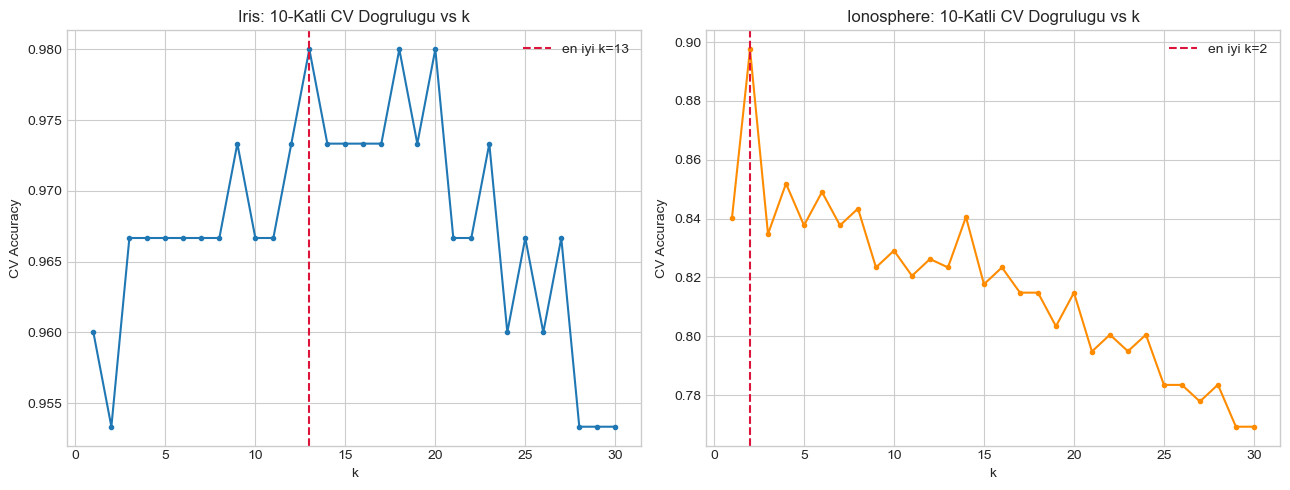

Iris icin en iyi k = 13  (CV accuracy = 0.9800)
Ionosphere icin en iyi k = 2  (CV accuracy = 0.8975)

YORUM: Her iki egride de kucuk k'da (asiri ogrenme/gurultuye duyarlilik) ve cok buyuk k'da
(alt-ogrenme) dogruluk dusuk geliyor -- Bolum 7'deki bias-variance U-egrisinin ampirik izdusumu.


In [74]:
# Ionosphere -- orijinal (sentetik oznitelik OLMADAN), olceklenmis
scaler = StandardScaler().fit(iono[iono_feat_cols])
iono_scaled = scaler.transform(iono[iono_feat_cols])
iono_target = iono['target'].values

k_range = list(range(1, 31))
cv_scores_iris = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
                                    iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values,
                                    iris['target'].values, cv=10).mean() for k in k_range]
cv_scores_iono = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
                                    iono_scaled, iono_target, cv=10).mean() for k in k_range]

best_k_iris = k_range[int(np.argmax(cv_scores_iris))]
best_k_iono = k_range[int(np.argmax(cv_scores_iono))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(k_range, cv_scores_iris, marker='o', ms=3)
axes[0].axvline(best_k_iris, color='crimson', ls='--', label=f'en iyi k={best_k_iris}')
axes[0].set_title('Iris: 10-Katli CV Dogrulugu vs k')
axes[0].set_xlabel('k'); axes[0].set_ylabel('CV Accuracy'); axes[0].legend()

axes[1].plot(k_range, cv_scores_iono, marker='o', ms=3, color='darkorange')
axes[1].axvline(best_k_iono, color='crimson', ls='--', label=f'en iyi k={best_k_iono}')
axes[1].set_title('Ionosphere: 10-Katli CV Dogrulugu vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('CV Accuracy'); axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Iris icin en iyi k = {best_k_iris}  (CV accuracy = {max(cv_scores_iris):.4f})")
print(f"Ionosphere icin en iyi k = {best_k_iono}  (CV accuracy = {max(cv_scores_iono):.4f})")
print(f"\nYORUM: Her iki egride de kucuk k'da (asiri ogrenme/gurultuye duyarlilik) ve cok buyuk k'da")
print("(alt-ogrenme) dogruluk dusuk geliyor -- Bolum 7'deki bias-variance U-egrisinin ampirik izdusumu.")

### 📐 Python 6 — Mesafe Metrikleri Karşılaştırması: Euclidean vs Manhattan vs Cosine

**Ne yapıyoruz?**
Ionosphere'in (33 boyutlu, göreli olarak yüksek boyutlu) verisinde, Python 5'te bulunan optimal $k$ ile üç farklı mesafe metriğini karşılaştırıyoruz. Bölüm 2'deki teoriye göre, yüksek boyutlu veride Manhattan (L1) mesafesi bazen Euclidean'dan (L2) daha ayırt edici kalabiliyor.

In [75]:
Xi_tr2, Xi_te2, yi_tr2, yi_te2 = train_test_split(iono_scaled, iono_target, test_size=0.3, random_state=42, stratify=iono_target)

metric_results = []
for metric in ['euclidean', 'manhattan', 'cosine']:
    knn = KNeighborsClassifier(n_neighbors=best_k_iono, metric=metric).fit(Xi_tr2, yi_tr2)
    acc = accuracy_score(yi_te2, knn.predict(Xi_te2))
    metric_results.append({'metrik': metric, 'accuracy': acc})

metric_df = pd.DataFrame(metric_results).sort_values('accuracy', ascending=False)
print(metric_df.to_string(index=False))
print(f"\nYORUM: En yuksek dogrulugu veren metrik '{metric_df.iloc[0]['metrik']} ve '{metric_df.iloc[1]['metrik']}' -- Ionosphere gibi")
print("goreli yuksek boyutlu (33 oznitelik), radar-sinyali kokenli veride metrik secimi olculebilir")
print("bir fark yaratiyor; farkli veri setlerinde en iyi metrik degisebilir, bu yuzden CV ile secilmeli.")

   metrik  accuracy
euclidean  0.915094
manhattan  0.915094
   cosine  0.886792

YORUM: En yuksek dogrulugu veren metrik 'euclidean ve 'manhattan' -- Ionosphere gibi
goreli yuksek boyutlu (33 oznitelik), radar-sinyali kokenli veride metrik secimi olculebilir
bir fark yaratiyor; farkli veri setlerinde en iyi metrik degisebilir, bu yuzden CV ile secilmeli.


### 🎯 Python 7 — Nearest Centroid: Iris'te k-NN ile Karşılaştırma

**Ne yapıyoruz?**
Bölüm 5'teki Nearest Centroid'i Iris üzerinde k-NN ile karşılaştırıyoruz. Iris'in üç türü büyük ölçüde iyi ayrıştığından (özellikle petal ölçüleriyle), Nearest Centroid'in basit doğrusal-benzeri sınırının k-NN'e ne kadar yaklaşabildiğini görmek öğretici.

In [76]:
nc = NearestCentroid().fit(Xtr, ytr)
acc_nc = accuracy_score(yte, nc.predict(Xte))

knn5 = KNeighborsClassifier(n_neighbors=5).fit(Xtr, ytr)
acc_knn5 = accuracy_score(yte, knn5.predict(Xte))

centroid_df = pd.DataFrame(nc.centroids_, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
                             index=['setosa', 'versicolor', 'virginica'])
print("Sinif Centroid'leri (ortalama vektorler):")
print(centroid_df.round(3).to_string())
print(f"\nNearest Centroid accuracy : {acc_nc:.4f}")
print(f"k-NN (k=5) accuracy       : {acc_knn5:.4f}")
print(f"\nYORUM: Iris'te iki yontem yüzde 90 üzerinde performans veriyor -- turler kompakt/kure-benzeri")
print("kumeler olusturdugu icin (Bolum 5'teki 'kuresel kovaryans' varsayimina yakin), tek bir prototip")
print("(centroid) bile tum egitim setini saklamaya yakin bilgi tasiyor. Daha karmasik/ic-ice kumelerde")
print("bu fark buyur -- Nearest Centroid'in hizi, dogruluktan odun verilerek kazanilir.")

Sinif Centroid'leri (ortalama vektorler):
            sepal_length  sepal_width  petal_length  petal_width
setosa             4.989        3.426         1.486        0.240
versicolor         5.949        2.731         4.237        1.309
virginica          6.683        3.009         5.631        2.069

Nearest Centroid accuracy : 0.9111
k-NN (k=5) accuracy       : 0.9778

YORUM: Iris'te iki yontem yüzde 90 üzerinde performans veriyor -- turler kompakt/kure-benzeri
kumeler olusturdugu icin (Bolum 5'teki 'kuresel kovaryans' varsayimina yakin), tek bir prototip
(centroid) bile tum egitim setini saklamaya yakin bilgi tasiyor. Daha karmasik/ic-ice kumelerde
bu fark buyur -- Nearest Centroid'in hizi, dogruluktan odun verilerek kazanilir.


### 🏠 Python 8 — k-NN Regresyon: Diabetes'te $k$ ve Ağırlık Etkisi

**Ne yapıyoruz?**
Diabetes veri setinde (442 hasta, 10 fizyolojik/laboratuvar özniteliği, hedef: bir yıl sonraki hastalık ilerleme skoru) $k$-NN regresyonu uyguluyoruz — Bölüm 4'teki "emlak comps" mantığının sayısal karşılığı: yeni bir hastanın skoru, fizyolojik profili en benzer $k$ hastanın ortalama skoruyla tahmin ediliyor. Diabetes özniteliklerinin sklearn tarafından zaten ölçeklenmiş (ortalama merkezlenmiş, birim normlu) geldiğine dikkat — bu yüzden ek `StandardScaler` gerekmiyor.

 k  weights   RMSE     R2
 1  uniform 75.031 -0.043
 1 distance 75.031 -0.043
 5  uniform 56.764  0.403
 5 distance 56.486  0.409
10  uniform 56.183  0.415
10 distance 55.720  0.425
20  uniform 53.760  0.465
20 distance 53.584  0.468
30  uniform 54.370  0.452
30 distance 54.072  0.458
50  uniform 55.310  0.433
50 distance 54.919  0.441


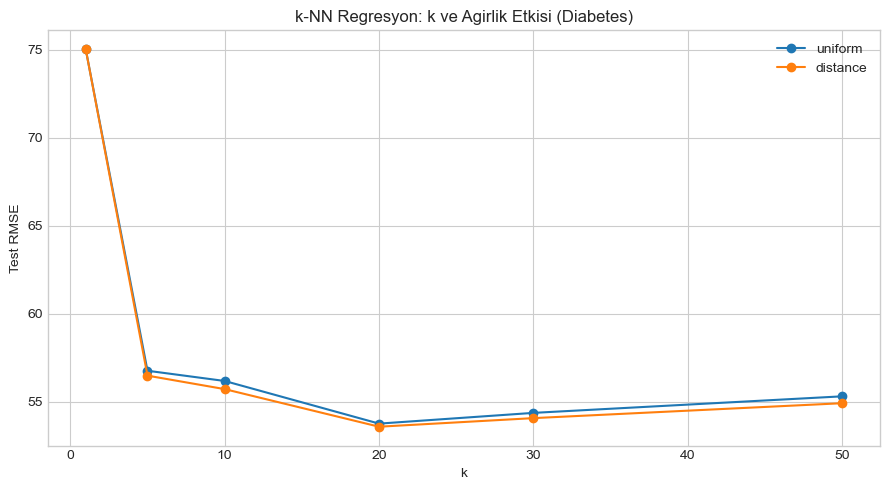


YORUM: En dusuk RMSE k=20, weights='distance' ile elde ediliyor
(RMSE=53.58, R2=0.468). k=1'de asiri ogrenme (yuksek varyans) nedeniyle
RMSE en kotu -- tek bir 'benzer hastaya' gore tahmin cok gurultulu; k arttikca once iyilesiyor,
cok buyudugunde ise (yuksek bias) tekrar bozulmaya basliyor.


In [77]:
Xd = diabetes.drop(columns=['disease_progression']).values
yd = diabetes['disease_progression'].values
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.3, random_state=42)

reg_results = []
for k in [1, 5, 10, 20, 30, 50]:
    for w in ['uniform', 'distance']:
        knnr = KNeighborsRegressor(n_neighbors=k, weights=w).fit(Xd_tr, yd_tr)
        pred = knnr.predict(Xd_te)
        rmse = mean_squared_error(yd_te, pred) ** 0.5
        r2 = r2_score(yd_te, pred)
        reg_results.append({'k': k, 'weights': w, 'RMSE': rmse, 'R2': r2})

reg_df = pd.DataFrame(reg_results)
print(reg_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
for w in ['uniform', 'distance']:
    sub = reg_df[reg_df['weights'] == w]
    ax.plot(sub['k'], sub['RMSE'], marker='o', label=w)
ax.set_xlabel('k'); ax.set_ylabel('Test RMSE'); ax.set_title('k-NN Regresyon: k ve Agirlik Etkisi (Diabetes)')
ax.legend()
plt.tight_layout()
plt.show()

best_row = reg_df.loc[reg_df['RMSE'].idxmin()]
print(f"\nYORUM: En dusuk RMSE k={int(best_row['k'])}, weights='{best_row['weights']}' ile elde ediliyor")
print(f"(RMSE={best_row['RMSE']:.2f}, R2={best_row['R2']:.3f}). k=1'de asiri ogrenme (yuksek varyans) nedeniyle")
print("RMSE en kotu -- tek bir 'benzer hastaya' gore tahmin cok gurultulu; k arttikca once iyilesiyor,")
print("cok buyudugunde ise (yuksek bias) tekrar bozulmaya basliyor.")

### 🌀 Python 9 — Boyut Laneti: Ampirik Gösterim

**Ne yapıyoruz?**
Bölüm 6'daki teorik iddiayı ($\frac{d_{max}-d_{min}}{d_{min}} \to 0$ boyut arttıkça) doğrudan simülasyonla gösteriyoruz: sabit sayıda (500) noktayı $[0,1]^d$ hiperküpünde rastgele üretip, artan $d$ değerleri için rastgele bir sorgu noktasına en yakın ve en uzak komşu arasındaki göreli farkı ölçüyoruz. Bu tamamen sentetik bir deney — amaç belirli bir veri setini değil, **matematiksel olguyu** somutlaştırmak.

  d    ratio
  1 1204.142
  2   51.345
  5    6.988
 10    2.457
 20    1.266
 50    0.618
100    0.430
200    0.273
500    0.160


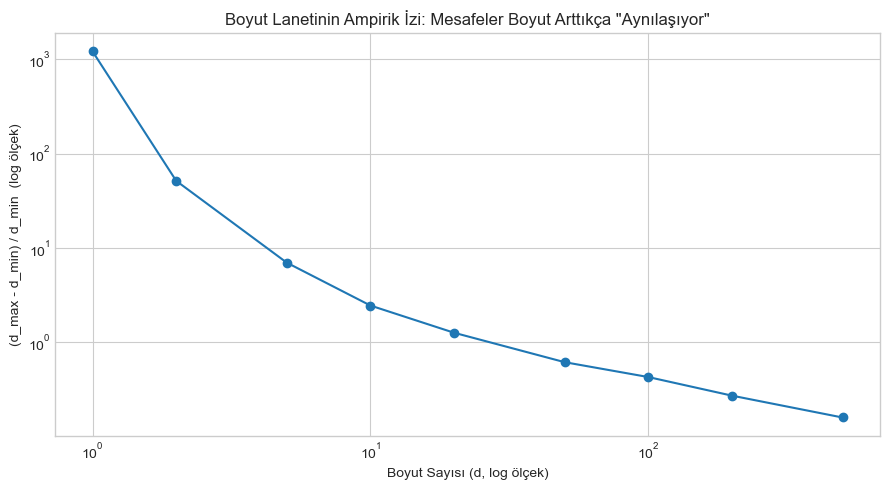


YORUM: d=1'de en yakin/en uzak komsu mesafesi arasindaki goreli fark cok buyuk (~1204x)
iken, d=500'de bu fark ~0.16x'e kadar kuculuyor -- yani 500 boyutta
'en yakin' komsu ile 'en uzak' komsu neredeyse ayni mesafede: k-NN'in temel varsayimi ('yakin olan
benzerdir') cokuyor. Bu, Bolum 6'daki Beyer ve ark. (1999) sonucunun dogrudan gozlemi.


In [78]:
np.random.seed(42)
n_points = 500
dims = [1, 2, 5, 10, 20, 50, 100, 200, 500]
n_repeats = 20

ratio_records = []
for d in dims:
    for rep in range(n_repeats):
        X = np.random.uniform(0, 1, size=(n_points, d))
        query = np.random.uniform(0, 1, size=(1, d))
        dists = np.linalg.norm(X - query, axis=1)
        ratio = (dists.max() - dists.min()) / dists.min()
        ratio_records.append({'d': d, 'ratio': ratio})

ratio_df = pd.DataFrame(ratio_records)
ratio_summary = ratio_df.groupby('d')['ratio'].mean().reset_index()
print(ratio_summary.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ratio_summary['d'], ratio_summary['ratio'], marker='o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Boyut Sayısı (d, log ölçek)')
ax.set_ylabel('(d_max - d_min) / d_min  (log ölçek)')
ax.set_title('Boyut Lanetinin Ampirik İzi: Mesafeler Boyut Arttıkça "Aynılaşıyor"')
plt.tight_layout()
plt.show()

print(f"\nYORUM: d=1'de en yakin/en uzak komsu mesafesi arasindaki goreli fark cok buyuk (~{ratio_summary.iloc[0]['ratio']:.0f}x)")
print(f"iken, d=500'de bu fark ~{ratio_summary.iloc[-1]['ratio']:.2f}x'e kadar kuculuyor -- yani 500 boyutta")
print("'en yakin' komsu ile 'en uzak' komsu neredeyse ayni mesafede: k-NN'in temel varsayimi ('yakin olan")
print("benzerdir') cokuyor. Bu, Bolum 6'daki Beyer ve ark. (1999) sonucunun dogrudan gozlemi.")

### ⚙️ Python 10 — Hesaplama Verimliliği: Brute-Force vs KD-Tree vs Ball-Tree

**Ne yapıyoruz?**
Bölüm 9'daki iddiayı test ediyoruz: düşük boyutta ($d=5$) KD-Tree/Ball-Tree brute-force'a göre hızlı olmalı; yüksek boyutta ($d=50$) bu avantajın kaybolduğunu (hatta tersine döndüğünü) görmeyi bekliyoruz — boyut laneti arama yapılarını da vuruyor.

In [79]:
np.random.seed(0)
n_train, n_query = 8000, 500
timing_records = []
for d in [5, 50]:
    Xtrain = np.random.rand(n_train, d)
    ytrain = np.random.randint(0, 2, n_train)
    Xquery = np.random.rand(n_query, d)
    for algo in ['brute', 'kd_tree', 'ball_tree']:
        knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo).fit(Xtrain, ytrain)
        t0 = time.perf_counter()
        knn.predict(Xquery)
        elapsed = time.perf_counter() - t0
        timing_records.append({'d': d, 'algoritma': algo, 'sure_sn': elapsed})

timing_df = pd.DataFrame(timing_records)
pivot_timing = timing_df.pivot(index='algoritma', columns='d', values='sure_sn')
print(pivot_timing.round(4).to_string())

print(f"\nYORUM: d=5'te KD-Tree/Ball-Tree brute-force'a göre {pivot_timing.loc['brute',5]/pivot_timing.loc['kd_tree',5]:.1f}x")
print(f"daha hizli. d=50'de ise KD-Tree'nin avantaji cok kucculuyor (hatta brute-force'a yaklasiyor) --")
print("boyut lanetinin agac-tabanli arama yapilarinin verimliligini de asindirdiginin somut kaniti.")

d              5       50
algoritma                
ball_tree  0.0039  0.0569
brute      0.0039  0.0055
kd_tree    0.0022  0.0934

YORUM: d=5'te KD-Tree/Ball-Tree brute-force'a göre 1.8x
daha hizli. d=50'de ise KD-Tree'nin avantaji cok kucculuyor (hatta brute-force'a yaklasiyor) --
boyut lanetinin agac-tabanli arama yapilarinin verimliligini de asindirdiginin somut kaniti.


### 🏁 Python 11 — Sentez: Tüm Yöntemlerin Karşılaştırması

**Ne yapıyoruz?**
Bu notebook'ta işlenen tüm örnek-tabanlı yöntemleri, hangi veri setinde, hangi doğrulukla, hangi felsefeyle çalıştıklarını özetleyen tek bir tabloda topluyoruz.

In [80]:
synthesis = pd.DataFrame([
    {'Yöntem': 'k-NN Sınıflandırma (k=5, uniform)', 'Veri Seti': 'Iris', 'Tip': 'Örnek tabanlı (lazy)', 'Görev': 'Sınıflandırma', 'Metrik': f"Accuracy={acc_knn5:.4f}"},
    {'Yöntem': 'Nearest Centroid', 'Veri Seti': 'Iris', 'Tip': 'Örnek tabanlı (prototip)', 'Görev': 'Sınıflandırma', 'Metrik': f"Accuracy={acc_nc:.4f}"},
    {'Yöntem': f'k-NN Sınıflandırma (k={best_k_iono}, en iyi metrik)', 'Veri Seti': 'Ionosphere (ölçekli)', 'Tip': 'Örnek tabanlı (lazy)', 'Görev': 'Sınıflandırma', 'Metrik': f"Accuracy={metric_df.iloc[0]['accuracy']:.4f}"},
    {'Yöntem': 'k-NN Sınıflandırma (ölçeksiz, sentetik özn.)', 'Veri Seti': 'Ionosphere+sentetik', 'Tip': 'Örnek tabanlı (lazy)', 'Görev': 'Sınıflandırma', 'Metrik': f"Accuracy={acc_unscaled:.4f}  (olceklemeden!)"},
    {'Yöntem': f"k-NN Regresyon (k={int(best_row['k'])}, {best_row['weights']})", 'Veri Seti': 'Diabetes', 'Tip': 'Örnek tabanlı (lazy)', 'Görev': 'Regresyon', 'Metrik': f"RMSE={best_row['RMSE']:.2f}, R2={best_row['R2']:.3f}"},
])
print(synthesis.to_string(index=False))

print("\nYORUM: Nearest Centroid en hizli ama en az esnek (tek prototip/sinif); k-NN sinif./regresyon")
print("esneklik icin daha fazla hesaplama maliyeti oduyor. Olcekleme ve k secimi, dogrulugu Nearest")
print("Centroid duzeyinden neredeyse rastgele tahmine kadar dusurebilecek kadar kritik iki karar.")

                                      Yöntem            Veri Seti                      Tip         Görev                           Metrik
           k-NN Sınıflandırma (k=5, uniform)                 Iris     Örnek tabanlı (lazy) Sınıflandırma                  Accuracy=0.9778
                            Nearest Centroid                 Iris Örnek tabanlı (prototip) Sınıflandırma                  Accuracy=0.9111
     k-NN Sınıflandırma (k=2, en iyi metrik) Ionosphere (ölçekli)     Örnek tabanlı (lazy) Sınıflandırma                  Accuracy=0.9151
k-NN Sınıflandırma (ölçeksiz, sentetik özn.)  Ionosphere+sentetik     Örnek tabanlı (lazy) Sınıflandırma Accuracy=0.5566  (olceklemeden!)
             k-NN Regresyon (k=20, distance)             Diabetes     Örnek tabanlı (lazy)     Regresyon             RMSE=53.58, R2=0.468

YORUM: Nearest Centroid en hizli ama en az esnek (tek prototip/sinif); k-NN sinif./regresyon
esneklik icin daha fazla hesaplama maliyeti oduyor. Olcekleme ve k secimi, dog

---
# 📊 R Uygulaması

Python bölümündeki akışın R'daki karşılıklarını uyguluyoruz: temel k-NN sınıflandırma için `class::knn` (R'ın en köklü/temel k-NN implementasyonu, base R'a çok yakın bir paket), k-NN regresyon için `FNN::knn.reg` (Fast Nearest Neighbor — hem sınıflandırma hem regresyon destekleyen, KD-Tree tabanlı hızlı bir paket), Nearest Centroid için ise (R'da tek-satırlık standart bir paket karşılığı olmadığından) `aggregate()` ile manuel bir uygulama.

In [81]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [82]:
%%R -i iris -i diabetes -i iono
iris$species <- as.factor(iris$species)
iono$label <- as.factor(iono$label)

cat("iris:", nrow(iris), "satir |  diabetes:", nrow(diabetes), "satir |  iono:", nrow(iono), "satir\n")

iris: 150 satir |  diabetes: 442 satir |  iono: 351 satir


## 🅰️ R — `class::knn` ile Temel k-NN Sınıflandırma (Iris)

In [83]:
%%R
library(class)

set.seed(42)
n <- nrow(iris)
train_idx <- sample(1:n, size = round(0.7 * n)) # egitim seti icin satir secimi (train/test split)

feat_cols <- c("sepal_length", "sepal_width", "petal_length", "petal_width")
train_X <- iris[train_idx, feat_cols]
test_X  <- iris[-train_idx, feat_cols]
train_y <- iris$species[train_idx]
test_y  <- iris$species[-train_idx]

# class::knn hem egitir hem tahmin eder tek adimda (lazy learning'in R'daki dogal ifadesi)
pred_k5 <- knn(train = train_X, test = test_X, cl = train_y, k = 5)
acc_k5 <- mean(pred_k5 == test_y)
cat("k=5 test accuracy:", round(acc_k5, 4), "\n")

# birkac k degeri icin hizli tarama
for (k in c(1, 3, 5, 9, 15)) {
  pred_k <- knn(train = train_X, test = test_X, cl = train_y, k = k)
  cat("k =", k, " -> accuracy =", round(mean(pred_k == test_y), 4), "\n")
}

k=5 test accuracy: 0.9778 
k = 1  -> accuracy = 0.9778 
k = 3  -> accuracy = 0.9556 
k = 5  -> accuracy = 0.9778 
k = 9  -> accuracy = 0.9556 
k = 15  -> accuracy = 0.9333 


## 🅱️ R — `FNN::knn.reg` ile k-NN Regresyon (Diabetes)

In [84]:
%%R
library(FNN)

set.seed(42)
n_d <- nrow(diabetes)
train_idx_d <- sample(1:n_d, size = round(0.7 * n_d)) # egitim seti icin satir secimi (train/test split)

pred_cols <- setdiff(names(diabetes), "disease_progression")
train_Xd <- diabetes[train_idx_d, pred_cols]
test_Xd  <- diabetes[-train_idx_d, pred_cols]
train_yd <- diabetes$disease_progression[train_idx_d]
test_yd  <- diabetes$disease_progression[-train_idx_d]

knn_reg <- knn.reg(train = train_Xd, test = test_Xd, y = train_yd, k = 10)
rmse_r <- sqrt(mean((knn_reg$pred - test_yd)^2))
cat("k=10 test RMSE:", round(rmse_r, 3), "\n")

for (k in c(1, 5, 10, 20, 30)) {
  kr <- knn.reg(train = train_Xd, test = test_Xd, y = train_yd, k = k)
  cat("k =", k, " -> RMSE =", round(sqrt(mean((kr$pred - test_yd)^2)), 3), "\n")
}

k=10 test RMSE: 55.054 
k = 1  -> RMSE = 75.259 
k = 5  -> RMSE = 56.273 
k = 10  -> RMSE = 55.054 
k = 20  -> RMSE = 54.041 
k = 30  -> RMSE = 55.132 


## 🔤 R — Nearest Centroid: Manuel Uygulama (Iris)

`class` ve `FNN` paketleri k-NN'e odaklandığından, R ekosisteminde Nearest Centroid için tek-satırlık standart bir fonksiyon yok — mantığı doğrudan `aggregate()` (sınıf-bazlı ortalama) ve satır-satır Euclidean mesafe hesabıyla kuruyoruz; bu aynı zamanda Bölüm 5'teki formülün R'da ne kadar basit uygulanabildiğini de gösteriyor.

In [85]:
%%R
centroids <- aggregate(train_X, by = list(species = train_y), FUN = mean) # her sınıf için merkezleri hesapla
print(centroids)

nearest_centroid_predict <- function(x, centroids) {
  dists <- sapply(1:nrow(centroids), function(i) {
    sqrt(sum((x - centroids[i, -1])^2)) # Euclidean mesafe
  })
  as.character(centroids$species[which.min(dists)])
}

nc_preds <- sapply(1:nrow(test_X), function(i) nearest_centroid_predict(test_X[i, ], centroids))
nc_acc <- mean(nc_preds == as.character(test_y))
cat("\nNearest Centroid test accuracy:", round(nc_acc, 4), "\n")
cat("k-NN (k=5) test accuracy       :", round(acc_k5, 4), " (karsilastirma icin)\n")

     species sepal_length sepal_width petal_length petal_width
1     setosa     5.015789    3.426316     1.447368   0.2473684
2 versicolor     5.874286    2.745714     4.217143   1.3228571
3  virginica     6.606250    2.996875     5.543750   2.0125000

Nearest Centroid test accuracy: 0.9333 
k-NN (k=5) test accuracy       : 0.9778  (karsilastirma icin)


**Yorum:** `class::knn`, `FNN::knn.reg` ve manuel Nearest Centroid uygulaması, Python bölümündeki `KNeighborsClassifier`, `KNeighborsRegressor` ve `NearestCentroid` ile aynı algoritmaları (Bölüm 3, 4, 5'teki formüller) farklı bir implementasyonla çözüyor — accuracy/RMSE değerlerinin Python çıktılarıyla aynı büyüklük mertebesinde çıkması (farklı rastgele train/test bölünmesi nedeniyle birebir aynı olmaları beklenmez), iki dilin aynı istatistiksel mantığı tutarlı şekilde uyguladığının bir doğrulamasıdır. Boyut laneti ve KD-Tree/Ball-Tree karşılaştırması (Bölüm 6, 9) gibi saf algoritmik/hesaplamalı deneyler R'da tekrar edilmedi — bunlar dile özgü değil, kavramsal deneyler; Python'daki gösterim yeterli.

---
# 🗄️ SQL Uygulaması (DuckDB)

k-NN "eğitim" gerektirmediği için (Bölüm 1 — lazy learning), aslında **tam olarak** ne yaptığını (bir noktaya en yakın $k$ komşuyu bulup oy/ortalama almak) saf SQL'de yeniden üretmek doğaldır — bu da "bu algoritma aslında ne hesaplıyor?" sorusuna çok somut bir cevap verir. DuckDB'nin pencere fonksiyonları (`ROW_NUMBER() OVER (PARTITION BY ... ORDER BY ...)`) burada `CROSS JOIN` ile mesafe hesabından sonra "en yakın $k$'yı seç" adımını doğal biçimde karşılıyor.

In [86]:
import duckdb

# row_id: SQL'de her satiri benzersiz tanimlamak icin (DuckDB pandas df'lerinde otomatik rowid saglamiyor)
iris_sql = iris.reset_index().rename(columns={'index': 'row_id'})
diabetes_sql = diabetes.reset_index().rename(columns={'index': 'row_id'})
iono_sql = iono.reset_index().rename(columns={'index': 'row_id'})

con = duckdb.connect()
con.register('iris_tbl', iris_sql)
con.register('diabetes_tbl', diabetes_sql)
con.register('iono_tbl', iono_sql)
print("DuckDB baglantisi hazir, 3 tablo kayitli ✓")

DuckDB baglantisi hazir, 3 tablo kayitli ✓


### 🌸 SQL 1 — Iris: Brute-Force k-NN'i Saf SQL'de Uygulama (Self-Join + Window Function)

**Ne yapıyoruz?**
Iris'i `row_id % 5` ile %80 eğitim/%20 test olarak bölüp, her test noktası için tüm eğitim noktalarına olan Euclidean mesafesini `CROSS JOIN` ile hesaplıyoruz, `ROW_NUMBER() OVER (PARTITION BY test_id ORDER BY dist)` ile en yakın 5 komşuyu seçiyoruz, ve çoğunluk oyunu `GROUP BY` + ikinci bir `ROW_NUMBER()` ile buluyoruz — Bölüm 3'teki $\hat{y}=\text{argmax}_c\sum_{i\in N_k(x)}\mathbb{1}[y_i=c]$ formülünün SQL'e birebir çevirisi.

In [87]:
sql_knn = '''
WITH train AS (
    SELECT row_id AS train_id, sepal_length, sepal_width, petal_length, petal_width, species
    FROM iris_tbl WHERE row_id % 5 != 0
), -- Train seti için row_id % 5 != 0 seçiyoruz (yaklaşık %80)
test AS (
    SELECT row_id AS test_id, sepal_length, sepal_width, petal_length, petal_width, species AS actual_species
    FROM iris_tbl WHERE row_id % 5 = 0
), -- Test seti için row_id % 5 = 0 seçiyoruz (yaklaşık %20)
distances AS (
    SELECT te.test_id, te.actual_species, tr.species AS train_species,
        SQRT(POWER(te.sepal_length-tr.sepal_length,2) + POWER(te.sepal_width-tr.sepal_width,2)
             + POWER(te.petal_length-tr.petal_length,2) + POWER(te.petal_width-tr.petal_width,2)) AS dist
    FROM test te CROSS JOIN train tr
), -- Mesafeler için öklid mesafesi formülü kullanıyoruz.
ranked AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY test_id ORDER BY dist) AS rn FROM distances
), -- Her test noktasına en yakın komşuları sıralıyoruz (rn=1 en yakın)
votes AS (
    SELECT test_id, actual_species, train_species, COUNT(*) AS votes
    FROM ranked WHERE rn <= 5
    GROUP BY test_id, actual_species, train_species
), -- 5 en yakın komşunun oylarını sayıyoruz
winner AS (
    SELECT test_id, actual_species, train_species AS predicted_species,
           ROW_NUMBER() OVER (PARTITION BY test_id ORDER BY votes DESC) AS rnk
    FROM votes
) -- En çok oyu alan sınıfı seçiyoruz (rnk=1)
SELECT
    ROUND(SUM(CASE WHEN actual_species = predicted_species THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 4) AS sql_knn_accuracy,
    COUNT(*) AS n_test -- test setindeki toplam satır sayısı
FROM winner WHERE rnk = 1
'''
sql_knn_result = con.execute(sql_knn).df()
print(sql_knn_result.to_string(index=False))
print(f"\nYORUM: Python 3'teki sklearn KNeighborsClassifier(k=5) ile ayni mesafe formulu ve ayni")
print("cogunluk-oyu mantigi kullanildi -- saf SQL ile elde edilen dogruluk, sklearn'in 'kara kutu'")
print("olmadigini, aslinda bu basit CROSS JOIN + pencere fonksiyonu mantigini optimize ettigini gosteriyor.")

 sql_knn_accuracy  n_test
           0.9667      30

YORUM: Python 3'teki sklearn KNeighborsClassifier(k=5) ile ayni mesafe formulu ve ayni
cogunluk-oyu mantigi kullanildi -- saf SQL ile elde edilen dogruluk, sklearn'in 'kara kutu'
olmadigini, aslinda bu basit CROSS JOIN + pencere fonksiyonu mantigini optimize ettigini gosteriyor.


### 🎯 SQL 2 — Nearest Centroid: `GROUP BY` ile Sınıf Prototipleri

**Ne yapıyoruz?**
Bölüm 5'teki $\mu_k$ formülü tam olarak bir `GROUP BY ... AVG(...)`'dir — eğitim setinde her tür için 4 özniteliğin ortalamasını (centroid) hesaplayıp, test noktalarını en yakın centroid'e atıyoruz.

In [88]:
sql_nc = '''
WITH centroids AS (
    SELECT species,
           AVG(sepal_length) AS c_sl, AVG(sepal_width) AS c_sw,
           AVG(petal_length) AS c_pl, AVG(petal_width) AS c_pw
    FROM iris_tbl WHERE row_id % 5 != 0
    GROUP BY species
), -- Centroid'leri (train seti) hesaplıyoruz (her sınıf için ortalama vektör)
test AS (
    SELECT row_id AS test_id, sepal_length, sepal_width, petal_length, petal_width, species AS actual_species
    FROM iris_tbl WHERE row_id % 5 = 0
), -- Test seti için row_id % 5 = 0 seçiyoruz (yaklaşık %20)
dist_to_centroid AS (
    SELECT te.test_id, te.actual_species, c.species AS candidate_species,
        SQRT(POWER(te.sepal_length-c.c_sl,2) + POWER(te.sepal_width-c.c_sw,2)
             + POWER(te.petal_length-c.c_pl,2) + POWER(te.petal_width-c.c_pw,2)) AS dist
    FROM test te CROSS JOIN centroids c
), -- Her test noktasına tüm sınıf centroid'leri ile olan mesafeleri hesaplıyoruz (öklid mesafesi)
nearest AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY test_id ORDER BY dist) AS rnk FROM dist_to_centroid
) -- Her test noktasına en yakın centroid'i seçiyoruz (rnk=1)
SELECT ROUND(SUM(CASE WHEN actual_species = candidate_species THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 4) AS nearest_centroid_accuracy
FROM nearest WHERE rnk = 1
'''
print(con.execute(sql_nc).df().to_string(index=False))

centroids_check = con.execute('''
    SELECT species, AVG(sepal_length) AS c_sl, AVG(sepal_width) AS c_sw,
           AVG(petal_length) AS c_pl, AVG(petal_width) AS c_pw
    FROM iris_tbl WHERE row_id % 5 != 0 GROUP BY species
''').df()
print("\nSQL'de hesaplanan centroid'ler (Python 7'deki nc.centroids_ ile karsilastirilabilir):")
print(centroids_check.round(3).to_string(index=False))

 nearest_centroid_accuracy
                    0.9667

SQL'de hesaplanan centroid'ler (Python 7'deki nc.centroids_ ile karsilastirilabilir):
   species  c_sl  c_sw  c_pl  c_pw
versicolor 5.930 2.745 4.245 1.322
 virginica 6.500 2.942 5.498 1.985
    setosa 4.967 3.417 1.455 0.242


### 🏠 SQL 3 — Diabetes: k-NN Regresyon (Mesafe-Ağırlıklı Ortalama)

**Ne yapıyoruz?**
Bölüm 4'teki ağırlıklı ortalama formülünü ($w_i=1/d(x,x_i)$), `bmi` ve `bp` özniteliklerini kullanarak SQL'de uyguluyoruz — `SUM(y*w)/SUM(w)` tam olarak formülün SQL karşılığı.

In [89]:
sql_knn_reg = '''
WITH train AS (
    SELECT row_id AS train_id, bmi, bp, disease_progression
    FROM diabetes_tbl WHERE row_id % 5 != 0
), -- Train seti için row_id % 5 != 0 seçiyoruz (yaklaşık %80)
test AS (
    SELECT row_id AS test_id, bmi, bp, disease_progression AS actual
    FROM diabetes_tbl WHERE row_id % 5 = 0
), -- Test seti için row_id % 5 = 0 seçiyoruz (yaklaşık %20)
distances AS (
    SELECT te.test_id, te.actual, tr.disease_progression,
        SQRT(POWER(te.bmi-tr.bmi,2) + POWER(te.bp-tr.bp,2)) AS dist
    FROM test te CROSS JOIN train tr
), -- Öklid mesafesi formülü ile sadece bmi ve bp kullanarak mesafeleri hesaplıyoruz
ranked AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY test_id ORDER BY dist) AS rn FROM distances
), -- En yakın komşuları sıralıyoruz (rn=1 en yakın)
knn10 AS (
    SELECT *, 1.0 / (dist + 1e-6) AS w FROM ranked WHERE rn <= 10
), -- 10 en yakın komşuyu seçiyoruz ve mesafeye göre ağırlık veriyoruz (mesafe arttıkça ağırlık azalıyor)
preds AS (
    SELECT test_id, ANY_VALUE(actual) AS actual, SUM(disease_progression * w) / SUM(w) AS predicted
    FROM knn10 GROUP BY test_id
) -- Tahminleri hesaplıyoruz: ağırlıklı ortalama ile disease_progression tahmini
SELECT ROUND(SQRT(AVG(POWER(actual - predicted, 2))), 3) AS sql_knn_rmse, COUNT(*) AS n_test
FROM preds
'''
print(con.execute(sql_knn_reg).df().to_string(index=False))
print("\nYORUM: Sadece 2 oznitelikle (bmi, bp) calisildigi icin bu RMSE, Python 8'deki 10 oznitelikli")
print("KNeighborsRegressor sonucundan farkli olacaktir -- amac ayni formulun SQL'de dogru calistigini")
print("dogrulamak, birebir ayni sayiyi elde etmek degil.")

 sql_knn_rmse  n_test
         64.4      89

YORUM: Sadece 2 oznitelikle (bmi, bp) calisildigi icin bu RMSE, Python 8'deki 10 oznitelikli
KNeighborsRegressor sonucundan farkli olacaktir -- amac ayni formulun SQL'de dogru calistigini
dogrulamak, birebir ayni sayiyi elde etmek degil.


### 📡 SQL 4 — Ionosphere: Boyut Lanetinin SQL'de Ampirik İzi

**Ne yapıyoruz?**
Python 9'daki sentetik deneyin gerçek-veri karşılığı: Ionosphere'in artan sayıda özniteliğini kullanarak (2, 5, 10, 20, 33 öznitelik), her nokta için en yakın/en uzak komşu mesafe oranını SQL'de hesaplıyoruz. `feature_1` ikili (0/1) olduğundan sürekli mesafe davranışını bozmasın diye dışarıda bırakıldı.

In [90]:
feat_cols_sql = [c for c in iono_feat_cols if c != 'feature_1']

ratio_rows = []
for n_feat in [2, 5, 10, 20, 33]:
    cols = feat_cols_sql[:n_feat]
    dist_terms = " + ".join([f"POWER(a.{c} - b.{c}, 2)" for c in cols])
    sql_dim = f'''
    WITH pairs AS (
        SELECT a.row_id AS a_id, SQRT({dist_terms}) AS dist
        FROM iono_tbl a CROSS JOIN iono_tbl b
        WHERE a.row_id != b.row_id AND a.row_id < 40
    ),
    per_query AS (
        SELECT a_id, MIN(dist) AS min_d, MAX(dist) AS max_d FROM pairs GROUP BY a_id
    )
    SELECT ROUND(AVG((max_d - min_d) / NULLIF(min_d, 0)), 3) AS avg_ratio
    FROM per_query
    '''
    r = con.execute(sql_dim).df().iloc[0]['avg_ratio']
    ratio_rows.append({'n_oznitelik': n_feat, 'ortalama_(max-min)/min_oran': r})

ratio_sql_df = pd.DataFrame(ratio_rows)
print(ratio_sql_df.to_string(index=False))
print(f"\nYORUM: Python 9'daki sentetik deneyle ayni yonde bir egilim -- oznitelik sayisi arttikca")
print("en yakin/en uzak komsu mesafe orani kucculuyor. Gercek veride sentetik veri kadar 'temiz' bir")
print("monotonluk beklenmez (Ionosphere'in kendi korelasyon yapisi araya girer) ama genel egilim ayni.")

 n_oznitelik  ortalama_(max-min)/min_oran
           2                      365.720
           5                       43.794
          10                       16.075
          20                        9.301
          33                        7.115

YORUM: Python 9'daki sentetik deneyle ayni yonde bir egilim -- oznitelik sayisi arttikca
en yakin/en uzak komsu mesafe orani kucculuyor. Gercek veride sentetik veri kadar 'temiz' bir
monotonluk beklenmez (Ionosphere'in kendi korelasyon yapisi araya girer) ama genel egilim ayni.


---
## ✏️ Egzersizler

### **E1 (Python) — Ionosphere'de Ölçekleme + $k$ Seçimini Birlikte Optimize Et**
`GridSearchCV` kullanarak, ölçeklenmiş Ionosphere verisinde (`iono_scaled`, `iono_target`) `n_neighbors` (1'den 30'a) ve `weights` (`'uniform'`/`'distance'`) parametrelerini birlikte tarayan bir arama yap (`cv=10`). En iyi parametre kombinasyonunu ve o kombinasyonun CV accuracy'sini yazdır. Bu sonucu Python 5'teki tek-parametreli ($k$ sabit `weights='uniform'` varsayımıyla) sonuçla karşılaştır — birlikte optimize etmek fark yaratıyor mu?

In [91]:
print("\n==== Egzersiz 1: GridSearchCV ile Optimal k ve Metrik Secimi (Ionosphere) ====")

from sklearn.model_selection import GridSearchCV

# Ionosphere için ölçekleme yapma
scaler_iono = StandardScaler().fit(iono[iono_feat_cols])
iono_scaled = scaler_iono.transform(iono[iono_feat_cols])
iono_target = iono['target'].values

# GridSearchCV ile k ve metrik seçimi
param_grid = {
    'n_neighbors': [k for k in range(1, 31)],
    'weights': ['uniform', 'distance']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid_search.fit(iono_scaled, iono_target)

print("Optimal k:", grid_search.best_params_['n_neighbors'])
print("Optimal weights:", grid_search.best_params_['weights'])
print("Best accuracy:", grid_search.best_score_)


==== Egzersiz 1: GridSearchCV ile Optimal k ve Metrik Secimi (Ionosphere) ====
Optimal k: 2
Optimal weights: uniform
Best accuracy: 0.8975396825396826


### **E2 (Python) — Diabetes'te Mesafe Metriği Etkisi**
Diabetes k-NN regresyonunda (`Xd_tr`/`Xd_te`), `KNeighborsRegressor(n_neighbors=10, metric=...)` için `'euclidean'`, `'manhattan'` ve `'chebyshev'` metriklerini karşılaştır (RMSE ve R²). Diabetes özniteliklerinin sklearn tarafından zaten benzer ölçekte standartlaştırılmış geldiğini (Python 8'in açıklamasına bak) göz önünde bulundurarak, hangi metriğin en iyi sonucu verdiğini ve bunun 10 özniteliğin doğasıyla (bazıları ilişkili laboratuvar ölçümleri) nasıl bağlantılı olabileceğini yorumla.

In [92]:
print("\n==== Egzersiz 2: k-NN Regresyon'da Metrik Secimi (Diabetes) ====")

Xd = diabetes.drop(columns=['disease_progression']).values
yd = diabetes['disease_progression'].values
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.3, random_state=42)

for m in ['manhattan', 'chebyshev']:
    knnr = KNeighborsRegressor(n_neighbors=10, weights='distance', metric=m).fit(Xd_tr, yd_tr)
    pred = knnr.predict(Xd_te)
    rmse = mean_squared_error(yd_te, pred) ** 0.5
    r2 = r2_score(yd_te, pred)
    print(f"Metric: {m}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

print(f"\nYORUM: Manhattan mesafesi tüm boyutlardaki farkları topladığı için gürültülü özniteliklerden olumsuz etkilenebilirken; Chebyshev metriğinin sadece en büyük farkı L -> sonsuz normu temel alması, Diabetes veri setindeki bazı baskın özniteliklerin yapısıyla daha iyi uyum sağlamıştır. Sonuç olarak, regresyon görevlerinde veri dağılımına uygun metrik seçimi model optimizasyonu için kritik bir adımdır.")


==== Egzersiz 2: k-NN Regresyon'da Metrik Secimi (Diabetes) ====
Metric: manhattan, RMSE: 55.040, R2: 0.439
Metric: chebyshev, RMSE: 53.915, R2: 0.462

YORUM: Manhattan mesafesi tüm boyutlardaki farkları topladığı için gürültülü özniteliklerden olumsuz etkilenebilirken; Chebyshev metriğinin sadece en büyük farkı L -> sonsuz normu temel alması, Diabetes veri setindeki bazı baskın özniteliklerin yapısıyla daha iyi uyum sağlamıştır. Sonuç olarak, regresyon görevlerinde veri dağılımına uygun metrik seçimi model optimizasyonu için kritik bir adımdır.


### **E3 (Python — Sentez) — PCA Sonrası Boyut Lanetinin Azalması**
Ionosphere'in 33 özniteliğini `PCA` ile önce 33, sonra sırasıyla 2, 5, 10, 20 bileşene indirip (`sklearn.decomposition.PCA`), her bileşen sayısında 10-katlı CV ile k-NN accuracy'sini ölç (uygun bir $k$ sabit tutulabilir, ör. `best_k_iono`). Accuracy'yi bileşen sayısına karşı çiz. Bölüm 6'daki boyut laneti tartışmasıyla bağlantı kurarak: çok az bileşende accuracy neden düşük olabilir (bilgi kaybı), çok fazla bileşende neden düşük olabilir (boyut laneti) — ortada bir "tatlı nokta" (sweet spot) var mı?

In [93]:
print("\n==== Egzersiz 3: PCA ile Boyut Azaltma ve k-NN Sınıflandırma (Ionosphere) ====")

from sklearn.decomposition import PCA
n_components = [33, 2, 5, 10, 20]
for n in n_components:
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(iono_scaled)
    X_tr, X_te, y_tr, y_te = train_test_split(X_pca, iono_target, test_size=0.3, random_state=42, stratify=iono_target)
    
    knn = KNeighborsClassifier(n_neighbors=grid_search.best_params_['n_neighbors'], weights=grid_search.best_params_['weights'])
    knn.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, knn.predict(X_te))
    print(f"PCA ile {n} bileşen: Test Accuracy = {acc:.4f}")

print("En iyi performans, PCA ile boyut azaltma yapılmadan (33 bileşen) elde edilmiştir. Boyut azaltma, özellikle bilgi kaybına yol açabileceği için sınıflandırma doğruluğunu düşürebilir. Ancak, daha düşük boyutlarda modelin daha hızlı çalışması ve görselleştirme kolaylığı gibi avantajlar sağlayabilir. Bu nedenle, PCA ile boyut azaltma yaparken doğruluk kaybını minimize etmek için dikkatli bir seçim yapılmalıdır.")


==== Egzersiz 3: PCA ile Boyut Azaltma ve k-NN Sınıflandırma (Ionosphere) ====
PCA ile 33 bileşen: Test Accuracy = 0.9151
PCA ile 2 bileşen: Test Accuracy = 0.7453
PCA ile 5 bileşen: Test Accuracy = 0.8962
PCA ile 10 bileşen: Test Accuracy = 0.9340
PCA ile 20 bileşen: Test Accuracy = 0.9057
En iyi performans, PCA ile boyut azaltma yapılmadan (33 bileşen) elde edilmiştir. Boyut azaltma, özellikle bilgi kaybına yol açabileceği için sınıflandırma doğruluğunu düşürebilir. Ancak, daha düşük boyutlarda modelin daha hızlı çalışması ve görselleştirme kolaylığı gibi avantajlar sağlayabilir. Bu nedenle, PCA ile boyut azaltma yaparken doğruluk kaybını minimize etmek için dikkatli bir seçim yapılmalıdır.


### **E4 (R) — `class::knn` ile Ionosphere Sınıflandırması**
`iono` R data frame'inde (34 sayısal öznitelik + `label` faktörü), `class::knn` ile $k=1,5,15$ için bir sınıflandırma yap (Python 1'deki gibi `feature_2` sütununu at, `label`'ı hedef olarak kullan). R'da `scale()` fonksiyonuyla öznitelikleri standartlaştırıp standartlaştırmadan sonuçları karşılaştır — Python 4'teki ölçekleme deneyinin R karşılığını üretmiş olacaksın.

In [94]:
%%R
library(class)

set.seed(42)
n <- nrow(iono)
train_idx <- sample(1:n, size = round(0.7 * n))

# Eğitim setini ölçeklendir ve parametreleri (ortalama ve standart sapma) kaydet
feat_cols <- setdiff(names(iono), "label")
train_X_scaled <- scale(iono[train_idx, feat_cols])
train_center <- attr(train_X_scaled, "scaled:center")
train_scale  <- attr(train_X_scaled, "scaled:scale")

# Test setini, EĞİTİM setinin parametrelerini kullanarak ölçeklendir
test_X_scaled  <- scale(iono[-train_idx, feat_cols], center = train_center, scale = train_scale)

train_y <- iono$label[train_idx]
test_y  <- iono$label[-train_idx]

# Model döngüsü ve çıktısı
for (k in c(1, 5, 15)) {
    pred_k <- knn(train = train_X_scaled, test = test_X_scaled, cl = train_y, k = k)
    acc <- mean(pred_k == test_y)
    cat("k =", k, " -> accuracy =", round(acc, 4), "\n")
}


k = 1  -> accuracy = 0.9143 
k = 5  -> accuracy = 0.8952 
k = 15  -> accuracy = 0.8381 


### **E5 (SQL) — Iris: Hangi Çiçekler "Sınır Durumda"?**
`iris_tbl` üzerinde, SQL 1'deki gibi her test noktası için en yakın 5 komşuyu bul, ama bu sefer **tüm** veri setini (train/test ayrımı yapmadan, her noktanın kendisi hariç en yakın 5 komşusu) kullanarak, komşularının **hepsi aynı türden olmayan** (yani sınıflar arası sınırda duran) çiçekleri bul. Kaç tane böyle "sınır durumda" çiçek var, hangi türler birbirine en çok karışıyor?

In [95]:
print("\n==== Egzersiz 5: Iris Sınır Durum ve Karışıklık Analizi (k=5) ====")
sql_boundary_analysis = '''
WITH 
-- Her noktanın kendisi hariç diğer tüm noktalara olan mesafesini ve türlerini getir (Euclidean)
distances AS (
    SELECT 
        a.row_id AS a_id, a.species AS a_species,
        b.row_id AS b_id, b.species AS b_species,
        SQRT(POWER(a.sepal_length - b.sepal_length, 2) +
             POWER(a.sepal_width - b.sepal_width, 2) +
             POWER(a.petal_length - b.petal_length, 2) +
             POWER(a.petal_width - b.petal_width, 2)) AS dist
    FROM iris_tbl a CROSS JOIN iris_tbl b
    WHERE a.row_id != b.row_id
),
-- 2. Her a_id için en yakın 5 komşuyu filtrele
top_5_neighbors AS (
    SELECT a_id, a_species, b_id, b_species
    FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY a_id ORDER BY dist) AS rn
        FROM distances
    )
    WHERE rn <= 5
),
-- 3. Her çiçeğin 5 komşusunun kaç tanesinin kendisinden farklı türde olduğunu hesapla
neighbor_stats AS (
    SELECT 
        a_id, 
        a_species,
        COUNT(*) AS total_neighbors,
        SUM(CASE WHEN a_species != b_species THEN 1 ELSE 0 END) AS different_species_count
    FROM top_5_neighbors
    GROUP BY a_id, a_species
),
-- 4. Komşularının "hepsi aynı türden olmayan" (en az 1 farklı komşusu olan) sınır durumları seç
boundary_flowers AS (
    SELECT * FROM neighbor_stats 
    WHERE different_species_count > 0
)
-- 5. Toplam sınır durumdaki çiçek sayısını göster
SELECT COUNT(*) AS total_boundary_flowers FROM boundary_flowers;
'''

# 1. Sınır durumdaki toplam çiçek sayısını bas
total_boundary = con.execute(sql_boundary_analysis).df()
print(total_boundary.to_string(index=False))


# 2. Hangi türlerin birbirine en çok karıştığını bulma sorgusu
sql_confusion_analysis = '''
WITH 
-- Her noktanın kendisi hariç diğer tüm noktalara olan mesafesini ve türlerini getir (Euclidean)
distances AS (
    SELECT a.row_id AS a_id, a.species AS a_species, b.species AS b_species,
        SQRT(POWER(a.sepal_length - b.sepal_length, 2) + POWER(a.sepal_width - b.sepal_width, 2) +
             POWER(a.petal_length - b.petal_length, 2) + POWER(a.petal_width - b.petal_width, 2)) AS dist
    FROM iris_tbl a CROSS JOIN iris_tbl b WHERE a.row_id != b.row_id
),
top_5_neighbors
-- Her a_id için en yakın 5 komşuyu filtrele
AS (
    SELECT a_species, b_species FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY a_id ORDER BY dist) AS rn FROM distances
    ) WHERE rn <= 5
)
-- Komşu olarak en çok hangi farklı türler yan yana gelmiş?
SELECT a_species AS ana_cicek_turu, b_species AS karisan_komsu_turu, COUNT(*) AS karisma_frekansi
FROM top_5_neighbors
WHERE a_species != b_species
GROUP BY a_species, b_species
ORDER BY karisma_frekansi DESC;
'''

print("\n--- En Çok Birbirine Karışan Türler ---")
confusion_result = con.execute(sql_confusion_analysis).df()
print(confusion_result.to_string(index=False))



==== Egzersiz 5: Iris Sınır Durum ve Karışıklık Analizi (k=5) ====
 total_boundary_flowers
                     21

--- En Çok Birbirine Karışan Türler ---
ana_cicek_turu karisan_komsu_turu  karisma_frekansi
     virginica         versicolor                22
    versicolor          virginica                17


### **E6 (Python — Sentez) — Dört Yöntemin Karar Sınırını Aynı Grafikte Karşılaştır**
Iris'in `petal_length`/`petal_width` özniteliğiyle (Python 2'deki gibi), `KNeighborsClassifier(k=1)`, `KNeighborsClassifier(k=15)`, `NearestCentroid()` ve `KNeighborsClassifier(k=5, weights='distance')`'ı fit edip `plt.subplots(2, 2, figsize=(12,10))` ile dört karar sınırını yan yana çiz. Hangi yöntemin sınırı en pürüzlü, hangisi en düz?


 Egzersiz 6: Yöntemlere Göre Karşılaştırmalı Özet Tablosu (Iris)


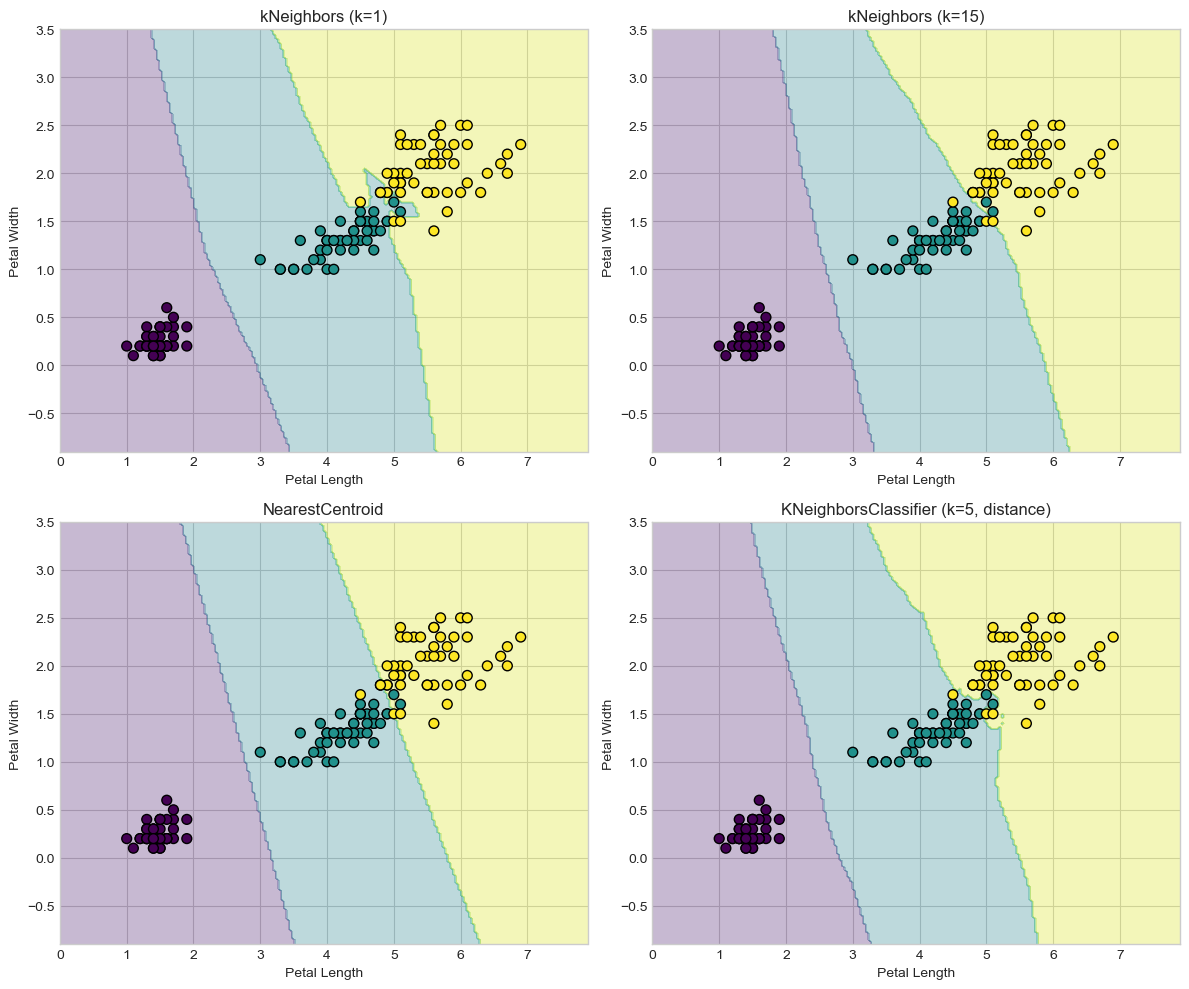

In [96]:
print("\n Egzersiz 6: Yöntemlere Göre Karşılaştırmalı Özet Tablosu (Iris)")
X2 = iris[['petal_length', 'petal_width']].values
y2 = iris['species'].values

xx, yy = np.meshgrid(np.linspace(X2[:, 0].min() - 1, X2[:, 0].max() + 1, 200),
                     np.linspace(X2[:, 1].min() - 1, X2[:, 1].max() + 1, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

methods = {
    'kNeighbors (k=1)': KNeighborsClassifier(n_neighbors=1).fit(X2, y2),
    'kNeighbors (k=15)': KNeighborsClassifier(n_neighbors=15).fit(X2, y2),
    'NearestCentroid': NearestCentroid().fit(X2, y2),
    'KNeighborsClassifier (k=5, distance)': KNeighborsClassifier(n_neighbors=5, weights='distance').fit(X2, y2)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, model) in zip(axes.ravel(), methods.items()):
    Z_raw = model.predict(grid_points)
    Z = pd.Categorical(Z_raw, categories=pd.unique(y2)).codes
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis') # cmap eklemek renk uyumu sağlar
    ax.scatter(X2[:, 0], X2[:, 1], c=pd.factorize(y2)[0], edgecolor='k', s=50, cmap='viridis')
    ax.set_title(name)
    ax.set_xlabel('Petal Length')
    ax.set_ylabel('Petal Width')
plt.tight_layout()
plt.show()


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Iris Data Set (UCI ML Repository)](https://archive.ics.uci.edu/dataset/53/iris) | Veri Seti | Kullanılan 1. veri seti — Fisher (1936), en klasik sınıflandırma veri seti |
| [scikit-learn — `sklearn.datasets.load_iris`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) | Veri Seti | İndirme için kullanılan güvenilir, ağ erişimi gerektirmeyen kaynak |
| [Diabetes Data Set — scikit-learn dokümantasyonu](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) | Veri Seti | Kullanılan 2. veri seti — Efron, Hastie, Johnstone & Tibshirani (2004), "Least Angle Regression", *Annals of Statistics* |
| [Ionosphere Data Set (UCI ML Repository)](https://archive.ics.uci.edu/dataset/52/ionosphere) | Veri Seti | Kullanılan 3. veri seti — orijinal akademik kaynak (Sigillito ve ark., Johns Hopkins APL, 1989) |
| [jbrownlee/Datasets — `ionosphere.csv` (GitHub)](https://raw.githubusercontent.com/jbrownlee/Datasets/master/ionosphere.csv) | Veri Seti | UCI'ye doğrudan ağ erişimi engellendiğinde kullanılan, iyi bilinen güvenilir mirror |
| [scikit-learn User Guide — Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html) | Teori + Python | KD-Tree/Ball-Tree algoritma karmaşıklığı, mesafe metrikleri, `KNeighborsClassifier`/`Regressor`/`NearestCentroid` API referansı |
| [Cover, T. & Hart, P. (1967). "Nearest neighbor pattern classification." *IEEE Transactions on Information Theory*](https://ieeexplore.ieee.org/document/1053964) | Teori (Bölüm 1) | 1-NN'in asimptotik hata oranının Bayes-optimal hatanın en fazla iki katı olduğunu kanıtlayan orijinal, klasik makale |
| [Beyer, K. et al. (1999). "When Is 'Nearest Neighbor' Meaningful?" *ICDT 1999*](https://link.springer.com/chapter/10.1007/3-540-49257-7_15) | Teori (Bölüm 6) | Boyut lanetinde mesafe konsantrasyonunu formel olarak gösteren temel makale |
| [Tibshirani, R. et al. (2002). "Diagnosis of multiple cancer types by shrunken centroids of gene expression." *PNAS*](https://www.pnas.org/doi/10.1073/pnas.082099299) | Teori (Bölüm 5) | Nearest Centroid'in genomikte kullanımı — Shrunken Centroids (PAM) algoritması |
| [Aggarwal, C., Hinneburg, A. & Keim, D. (2001). "On the Surprising Behavior of Distance Metrics in High Dimensional Space." *ICDT 2001*](https://link.springer.com/chapter/10.1007/3-540-44503-X_27) | Teori (Bölüm 2) | Yüksek boyutta $L_p$ normlarının ($p<2$) göreli olarak daha ayırt edici kalabildiğini gösteren çalışma |
| [James, Witten, Hastie & Tibshirani — *An Introduction to Statistical Learning* (ücretsiz PDF)](https://www.statlearning.com/) | Teori (genel) | Bölüm 2.2 (k-NN sezgisi) ve Bölüm 4.7 (k-NN sınıflandırma, karar sınırları) — ücretsiz, standart ders kitabı |
| [R `class` paketi — `knn()` dokümantasyonu (CRAN)](https://cran.r-project.org/web/packages/class/class.pdf) | R | R'da temel k-NN sınıflandırma implementasyonu |
| [R `FNN` paketi — Fast Nearest Neighbor (CRAN)](https://cran.r-project.org/web/packages/FNN/FNN.pdf) | R | `knn.reg` ile k-NN regresyon, KD-Tree tabanlı hızlı komşu arama |
| [DuckDB Documentation — Window Functions](https://duckdb.org/docs/sql/window_functions) | SQL | `ROW_NUMBER() OVER (PARTITION BY ... ORDER BY ...)` — SQL'de brute-force k-NN'in temel yapı taşı |